# Input / Output (I/O)
> Universal image loaders and readers for bioMONAI, fully compatible with the standard MONAI ecosystem.

The `bioMONAI.io` module provides a robust, format-agnostic interface for reading and preprocessing bioimages. It acts as a wrapper around powerful backends like `AICSImageIO` and standard libraries (`PIL`, `NumPy`, `HDF5`), seamlessly translating complex multidimensional arrays (e.g., CZI, OME-TIFF) into MONAI-compatible `MetaTensor` objects.

**Key Features:**
- **Universal Reader:** Automatically routes files to the correct backend based on extensions.
- **Lazy Loading:** Stream large sequences of images without blowing up RAM.
- **MONAI Integration:** Drop-in replacements (`BioImageReader`) for MONAI's standard data pipelines.
- **On-the-fly Transforms:** Apply MONAI spatial and intensity transforms during the initial load.

In [ ]:
#| default_exp io

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import time
import re
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any

# =================================
# Scientific / data
# =================================
import h5py
import numpy as np
import xarray as xr

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as writer
from bioio_tifffile import Reader as TiffReader
from bioio_ome_tiff import Reader as OmeTiffReader
from bioio_czi import Reader as CziReader
from bioio_imageio import Reader as IOReader

# =================================
# Medical imaging
# =================================
from torchio import ScalarImage

# =================================
# fastai
# =================================
from fastai.data.all import *
from fastai.vision.all import *

# =================================
# MONAI
# =================================
from monai.transforms import LoadImage, LoadImaged, SaveImage, SaveImaged
from monai.data.image_reader import ImageReader
from collections.abc import Callable, Iterable, Sequence
from monai.config import PathLike
from monai.data import MetaTensor
from monai.data.utils import is_supported_format
from monai.utils import MetaKeys

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *


## Image Containers
> Core data structures to securely bind multidimensional pixel arrays with their spatial metadata.

* **`ScalarImage`**: A TorchIO-backed container for medical images whose pixel values represent scalars (e.g., MRI, CT, or grayscale fluorescence).

In [ ]:
#| export
ScalarImage = ScalarImage

In [ ]:
show_doc(ScalarImage)

---

### ScalarImage

```python

def ScalarImage(
    args:VAR_POSITIONAL, kwargs:VAR_KEYWORD
):


```

*Image whose pixel values represent scalars.*

Example:
    >>> import torch
    >>> import torchio as tio
    >>> # Loading from a file
    >>> t1_image = tio.ScalarImage('t1.nii.gz')
    >>> dmri = tio.ScalarImage(tensor=torch.rand(32, 128, 128, 88))
    >>> image = tio.ScalarImage('safe_image.nrrd', check_nans=False)
    >>> data, affine = image.data, image.affine
    >>> affine.shape
    (4, 4)
    >>> image.data is image[tio.DATA]
    True
    >>> image.data is image.tensor
    True
    >>> type(image.data)
    torch.Tensor

See :class:`~torchio.Image` for more information.

--- Example: tio.ScalarImage (Medical Volume Container) ---
Data shape: torch.Size([1, 60, 256, 256]) | Type: Tensor
Affine shape: (4, 4)


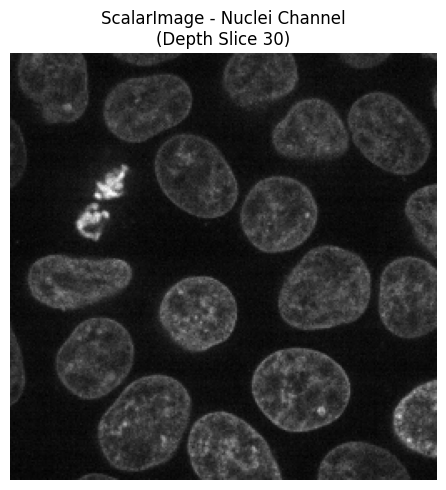

In [ ]:
# Example: Using ScalarImage with Real Biological 3D Data
import torch
import torchio as tio
import matplotlib.pyplot as plt
from skimage.data import cells3d

print("--- Example: tio.ScalarImage (Medical Volume Container) ---")

# 1. Load a real 3D volume (cells3d returns Z, C, Y, X -> 60, 2, 256, 256)
# We select the nuclei channel (index 1) and format it to (C, D, H, W) for TorchIO
volume_np = cells3d()[:, 1, :, :]
tensor_3d = torch.as_tensor(volume_np).unsqueeze(0).float()

# 2. Initialize ScalarImage
img_scalar = tio.ScalarImage(tensor=tensor_3d)

# 3. Access underlying data
data = img_scalar.data
print(f"Data shape: {data.shape} | Type: {type(data).__name__}")
print(f"Affine shape: {img_scalar.affine.shape}")

# VISUALIZATION (Mid-slice of the 3D volume)
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# We extract slice 30 (middle of the Z axis) and normalize to [0, 1] for display
mid_slice = data[0, 30].numpy()
mid_slice = (mid_slice - mid_slice.min()) / (mid_slice.max() - mid_slice.min())

ax.imshow(mid_slice, cmap='gray', vmin=0, vmax=1)
ax.set_title("ScalarImage - Nuclei Channel\n(Depth Slice 30)")
ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import torch
import torchio as tio

def test_scalar_image():
    # Test ScalarImage initialization and data accessors
    tensor_in = torch.rand(1, 10, 10, 10)
    img = tio.ScalarImage(tensor=tensor_in)
    
    # Verify data access methods point to the exact same memory
    test_eq(img.data is img[tio.DATA], True)
    test_eq(img.data is img.tensor, True)
    
    # Verify types and shapes
    test_eq(isinstance(img.data, torch.Tensor), True)
    test_eq(img.data.shape, (1, 10, 10, 10))
    test_eq(img.affine.shape, (4, 4))
    
    return "ScalarImage tests passed"

test_eq(test_scalar_image(), "ScalarImage tests passed")

#### `ScalarImage` Class Attributes & Parameter Reference

`ScalarImage` is a re-export of `torchio.ScalarImage`. It acts as the core container for medical images whose pixel values represent scalars (e.g., T1-weighted MRI, CT scans, grayscale ultrasounds), securely bundling the multidimensional pixel array with its spatial metadata (the 4x4 affine matrix). 

For deeper technical details, refer to the official [`torchio.Image` documentation](https://torchio.readthedocs.io/core/image.html).

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`tensor`** | `torch.Tensor` / `ndarray` | (Optional) Multidimensional array containing the image data. Expected layout is usually 4D `(Channels, Depth, Height, Width)`. |
| **`path`** | `str` / `Path` | (Optional) File path to load the image directly from disk (e.g., `.nii.gz`, `.nrrd`). |
| **`affine`** | `torch.Tensor` / `ndarray` | (Optional) 4x4 matrix defining the spatial coordinates, orientation, and voxel spacing. Defaults to an identity matrix if not provided. |
| **`check_nans`** | `bool` | If `True`, automatically checks for `NaN` (Not a Number) values during initialization to prevent silent errors downstream (default: `True`). |

## Image Writers
> Robust writers to export processed tensors back to physical files on disk, preserving spatial geometry and headers.

* **`SaveImage`**: Standard transform to save a PyTorch tensor to a physical file (e.g., NIfTI, TIFF, PNG).
* **`SaveImaged`**: Dictionary-based counterpart to save tensors stored within specific keys of a data dictionary.

In [ ]:
#| export
SaveImage = SaveImage
SaveImaged = SaveImaged

In [ ]:
show_doc(SaveImage)

---

### SaveImage

```python

def SaveImage(
    output_dir:PathLike='./', output_postfix:str='trans', output_ext:str='.nii.gz',
    output_dtype:DtypeLike | None=float32, resample:bool=False, mode:str='nearest', padding_mode:str=border,
    scale:int | None=None, dtype:DtypeLike=float64, squeeze_end_dims:bool=True, data_root_dir:PathLike='',
    separate_folder:bool=True, print_log:bool=True, output_format:str='',
    writer:type[image_writer.ImageWriter] | str | None=None, channel_dim:int | None=0,
    output_name_formatter:Callable[[dict, Transform], dict] | None=None, folder_layout:FolderLayoutBase | None=None,
    savepath_in_metadict:bool=False
)->None:


```

*Save the image (in the form of torch tensor or numpy ndarray) and metadata dictionary into files.*

The name of saved file will be `{input_image_name}_{output_postfix}{output_ext}`,
where the `input_image_name` is extracted from the provided metadata dictionary.
If no metadata provided, a running index starting from 0 will be used as the filename prefix.

Args:
    output_dir: output image directory.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_postfix: a string appended to all output file names, default to `trans`.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_ext: output file extension name.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_dtype: data type (if not None) for saving data. Defaults to ``np.float32``.
    resample: whether to resample image (if needed) before saving the data array,
        based on the ``"spatial_shape"`` (and ``"original_affine"``) from metadata.
    mode: This option is used when ``resample=True``. Defaults to ``"nearest"``.
        Depending on the writers, the possible options are

        - {``"bilinear"``, ``"nearest"``, ``"bicubic"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
        - {``"nearest"``, ``"linear"``, ``"bilinear"``, ``"bicubic"``, ``"trilinear"``, ``"area"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#interpolate

    padding_mode: This option is used when ``resample = True``. Defaults to ``"border"``.
        Possible options are {``"zeros"``, ``"border"``, ``"reflection"``}
        See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
    scale: {``255``, ``65535``} postprocess data by clipping to [0, 1] and scaling
        [0, 255] (``uint8``) or [0, 65535] (``uint16``). Default is ``None`` (no scaling).
    dtype: data type during resampling computation. Defaults to ``np.float64`` for best precision.
        if ``None``, use the data type of input data. To set the output data type, use ``output_dtype``.
    squeeze_end_dims: if ``True``, any trailing singleton dimensions will be removed (after the channel
        has been moved to the end). So if input is (C,H,W,D), this will be altered to (H,W,D,C), and
        then if C==1, it will be saved as (H,W,D). If D is also 1, it will be saved as (H,W). If ``False``,
        image will always be saved as (H,W,D,C).
    data_root_dir: if not empty, it specifies the beginning parts of the input file's
        absolute path. It's used to compute ``input_file_rel_path``, the relative path to the file from
        ``data_root_dir`` to preserve folder structure when saving in case there are files in different
        folders with the same file names. For example, with the following inputs:

        - input_file_name: ``/foo/bar/test1/image.nii``
        - output_postfix: ``seg``
        - output_ext: ``.nii.gz``
        - output_dir: ``/output``
        - data_root_dir: ``/foo/bar``

        The output will be: ``/output/test1/image/image_seg.nii.gz``

        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    separate_folder: whether to save every file in a separate folder. For example: for the input filename
        ``image.nii``, postfix ``seg`` and ``folder_path`` ``output``, if ``separate_folder=True``, it will be
        saved as: ``output/image/image_seg.nii``, if ``False``, saving as ``output/image_seg.nii``.
        Default to ``True``.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    print_log: whether to print logs when saving. Default to ``True``.
    output_format: an optional string of filename extension to specify the output image writer.
        see also: ``monai.data.image_writer.SUPPORTED_WRITERS``.
    writer: a customised ``monai.data.ImageWriter`` subclass to save data arrays.
        if ``None``, use the default writer from ``monai.data.image_writer`` according to ``output_ext``.
        if it's a string, it's treated as a class name or dotted path (such as ``"monai.data.ITKWriter"``);
        the supported built-in writer classes are ``"NibabelWriter"``, ``"ITKWriter"``, ``"PILWriter"``.
    channel_dim: the index of the channel dimension. Default to ``0``.
        ``None`` to indicate no channel dimension.
    output_name_formatter: a callable function (returning a kwargs dict) to format the output file name.
        If using a custom ``monai.data.FolderLayoutBase`` class in ``folder_layout``, consider providing
        your own formatter.
        see also: :py:func:`monai.data.folder_layout.default_name_formatter`.
    folder_layout: A customized ``monai.data.FolderLayoutBase`` subclass to define file naming schemes.
        if ``None``, uses the default ``FolderLayout``.
    savepath_in_metadict: if ``True``, adds a key ``"saved_to"`` to the metadata, which contains the path
        to where the input image has been saved.

In [ ]:
show_doc(SaveImaged)

---

### SaveImaged

```python

def SaveImaged(
    keys:KeysCollection, meta_keys:KeysCollection | None=None, meta_key_postfix:str='meta_dict',
    output_dir:Path | str='./', output_postfix:str='trans', output_ext:str='.nii.gz', resample:bool=False,
    mode:str='nearest', padding_mode:str=border, scale:int | None=None, dtype:DtypeLike=float64,
    output_dtype:DtypeLike | None=float32, allow_missing_keys:bool=False, squeeze_end_dims:bool=True,
    data_root_dir:str='', separate_folder:bool=True, print_log:bool=True, output_format:str='',
    writer:type[image_writer.ImageWriter] | str | None=None,
    output_name_formatter:Callable[[dict, Transform], dict] | None=None,
    folder_layout:monai.data.FolderLayoutBase | None=None, savepath_in_metadict:bool=False
)->None:


```

*Dictionary-based wrapper of :py:class:`monai.transforms.SaveImage`.*

Note:
    Image should be channel-first shape: [C,H,W,[D]].
    If the data is a patch of an image, the patch index will be appended to the filename.

Args:
    keys: keys of the corresponding items to be transformed.
        See also: :py:class:`monai.transforms.compose.MapTransform`
    meta_keys: explicitly indicate the key of the corresponding metadata dictionary.
        For example, for data with key ``image``, the metadata by default is in ``image_meta_dict``.
        The metadata is a dictionary contains values such as ``filename``, ``original_shape``.
        This argument can be a sequence of strings, mapped to the ``keys``.
        If ``None``, will try to construct ``meta_keys`` by ``key_{meta_key_postfix}``.
    meta_key_postfix: if ``meta_keys`` is ``None``, use ``key_{meta_key_postfix}`` to retrieve the metadict.
    output_dir: output image directory.
                Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_postfix: a string appended to all output file names, default to ``trans``.
                    Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    output_ext: output file extension name, available extensions: ``.nii.gz``, ``.nii``, ``.png``, ``.dcm``.
                Handled by ``folder_layout`` instead, if ``folder_layout`` not ``None``.
    resample: whether to resample image (if needed) before saving the data array,
        based on the ``spatial_shape`` (and ``original_affine``) from metadata.
    mode: This option is used when ``resample=True``. Defaults to ``"nearest"``.
        Depending on the writers, the possible options are:

        - {``"bilinear"``, ``"nearest"``, ``"bicubic"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
        - {``"nearest"``, ``"linear"``, ``"bilinear"``, ``"bicubic"``, ``"trilinear"``, ``"area"``}.
          See also: https://pytorch.org/docs/stable/nn.functional.html#interpolate

    padding_mode: This option is used when ``resample = True``. Defaults to ``"border"``.
        Possible options are {``"zeros"``, ``"border"``, ``"reflection"``}
        See also: https://pytorch.org/docs/stable/nn.functional.html#grid-sample
    scale: {``255``, ``65535``} postprocess data by clipping to [0, 1] and scaling
        [0, 255] (``uint8``) or [0, 65535] (``uint16``). Default is ``None`` (no scaling).
    dtype: data type during resampling computation. Defaults to ``np.float64`` for best precision.
        if None, use the data type of input data. To set the output data type, use ``output_dtype``.
    output_dtype: data type for saving data. Defaults to ``np.float32``.
    allow_missing_keys: don't raise exception if key is missing.
    squeeze_end_dims: if True, any trailing singleton dimensions will be removed (after the channel
        has been moved to the end). So if input is (C,H,W,D), this will be altered to (H,W,D,C), and
        then if C==1, it will be saved as (H,W,D). If D is also 1, it will be saved as (H,W). If `false`,
        image will always be saved as (H,W,D,C).
    data_root_dir: if not empty, it specifies the beginning parts of the input file's
        absolute path. It's used to compute ``input_file_rel_path``, the relative path to the file from
        ``data_root_dir`` to preserve folder structure when saving in case there are files in different
        folders with the same file names. For example, with the following inputs:

        - input_file_name: ``/foo/bar/test1/image.nii``
        - output_postfix: ``seg``
        - output_ext: ``.nii.gz``
        - output_dir: ``/output``
        - data_root_dir: ``/foo/bar``

        The output will be: ``/output/test1/image/image_seg.nii.gz``

        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    separate_folder: whether to save every file in a separate folder. For example: for the input filename
        ``image.nii``, postfix ``seg`` and folder_path ``output``, if ``separate_folder=True``, it will be saved as:
        ``output/image/image_seg.nii``, if ``False``, saving as ``output/image_seg.nii``. Default to ``True``.
        Handled by ``folder_layout`` instead, if ``folder_layout`` is not ``None``.
    print_log: whether to print logs when saving. Default to ``True``.
    output_format: an optional string to specify the output image writer.
        see also: ``monai.data.image_writer.SUPPORTED_WRITERS``.
    writer: a customised ``monai.data.ImageWriter`` subclass to save data arrays.
        if ``None``, use the default writer from ``monai.data.image_writer`` according to ``output_ext``.
        if it's a string, it's treated as a class name or dotted path;
        the supported built-in writer classes are ``"NibabelWriter"``, ``"ITKWriter"``, ``"PILWriter"``.
    output_name_formatter: a callable function (returning a kwargs dict) to format the output file name.
        see also: :py:func:`monai.data.folder_layout.default_name_formatter`.
        If using a custom ``folder_layout``, consider providing your own formatter.
    folder_layout: A customized ``monai.data.FolderLayoutBase`` subclass to define file naming schemes.
        if ``None``, uses the default ``FolderLayout``.
    savepath_in_metadict: if ``True``, adds a key ``saved_to`` to the metadata, which contains the path
        to where the input image has been saved.

In [ ]:
# Example: Saving a Medical Volume securely using SaveImage
import tempfile
import os
import torch
from monai.transforms import SaveImage
from skimage.data import cells3d

print("--- Example: SaveImage (NIfTI / Medical Format Writer) ---")

# 1. Load real 3D volume (nuclei channel) and add batch/channel dims -> (1, 60, 256, 256)
volume = cells3d()[:, 1, :, :]
tensor_vol = torch.as_tensor(volume).unsqueeze(0).float()

# 2. We use a temporary directory to avoid polluting your disk during documentation build
with tempfile.TemporaryDirectory() as temp_dir:
    # Initialize the writer (defaults to .nii.gz)
    saver = SaveImage(output_dir=temp_dir, output_postfix="processed", output_ext=".nii.gz", print_log=False)
    
    # 3. Save the tensor. We pass dummy metadata so MONAI knows how to name the file
    saver(tensor_vol, meta_data={"filename_or_obj": "cells3d_volume"})
    
    # Verify saved file
    saved_files = os.listdir(temp_dir)
    print(f"Output Directory: {temp_dir}")
    print(f"Files saved successfully: {saved_files}")
    
    # Temporary directory cleans itself up automatically after this block

--- Example: SaveImage (NIfTI / Medical Format Writer) ---
Output Directory: /tmp/tmp6zvg4f88
Files saved successfully: ['cells3d_volume']


In [ ]:
#| hide
from fastcore.test import test_eq
import torch
import tempfile
import os
from monai.transforms import SaveImage

def test_save_image():
    # Test SaveImage functionality mathematically by ensuring the file writes correctly
    tensor_test = torch.ones(1, 10, 10, 10)
    
    with tempfile.TemporaryDirectory() as tmp:
        # separate_folder=False forces MONAI to save directly in tmp, without creating subdirectories
        saver = SaveImage(
            output_dir=tmp, 
            output_postfix="test", 
            output_ext=".nii.gz", 
            separate_folder=False, 
            print_log=False
        )
        saver(tensor_test, meta_data={"filename_or_obj": "dummy"})
        
        files = os.listdir(tmp)
        test_eq(len(files), 1)
        test_eq("dummy_test.nii.gz" in files, True)
        
    return "SaveImage tests passed"

test_eq(test_save_image(), "SaveImage tests passed")

#### `SaveImage` & `SaveImaged` Class Attributes & Parameter Reference

These classes are direct re-exports of MONAI's image writers. They provide a standardized, highly configurable way to export PyTorch Tensors or NumPy arrays back to physical files on disk (typically `.nii.gz` or `.png`/`.tif`), preserving spatial geometry and headers.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`output_dir`** | `str` / `Path` | The destination directory for the saved images (default: `'./'`). |
| **`output_postfix`** | `str` | A string appended to the end of the original filename before the extension (default: `'trans'`). |
| **`output_ext`** | `str` | The desired file extension, which automatically determines the writer backend used (default: `'.nii.gz'`). |
| **`resample`** | `bool` | If `True`, the image is automatically resampled back to its original physical space based on the affine matrix before saving (default: `False`). |
| **`separate_folder`** | `bool` | If `True`, saves each image in its own sub-folder named after the original file (default: `True`). |
| **`keys`** | `list` | *(Only for `SaveImaged`)* Dictionary keys specifying which tensors should be saved to disk. |

## Image Loaders
> Core public classes for reading, standardizing, and preprocessing biological imaging data into MONAI-compatible MetaTensors.

This module provides the primary entry points for data loading in your deep learning pipelines. Built on top of a robust internal routing system and specialized bio-imaging backends (like `bioio`), these loaders automatically orchestrate several subsystems:

* **Multi-Format Ingestion:** Seamlessly read complex multidimensional formats (Ome-TIFF, CZI, HDF5) alongside standard formats (PNG, JPEG, Numpy arrays) via a dynamic registry system.
* **Dimension Wrangling:** Automatically slice (`ind_dict`), reorder, and pad axes to guarantee a consistent tensor layout across your dataset (e.g., forcing all inputs to a uniform `CZYX` structure).
* **Metadata Preservation:** Extract and inject critical spatial information, format details, and transform execution histories directly into the `MetaTensor`'s metadata dictionary.
* **Lazy Streaming:** Utilize efficient generator pipelines to lazily evaluate and yield preprocessed samples, minimizing memory overhead when working with massive biological datasets.
* **MONAI Integration:** Fully compatible with the MONAI ecosystem, offering both sequence-based and dictionary-based implementations to fit any workflow.

### Utils
> A collection of lightweight helper functions and data structures for string parsing, path splitting, format detection, and fast metadata extraction.

* **`tiff2torch`**: Directly loads standard TIFF files into PyTorch tensors bypassing complex backends.
* **`string2dict`**: Parses complex layout and slicing strings (e.g., `X[10:20:2]Z0`) into structured Python dictionaries.
* **`split_path`**: Separates compound strings containing both a physical file path and appended Region of Interest (ROI) instructions.
* **`is_ome_tiff`**: Evaluates file suffixes to quickly verify if a path strictly points to an OME-TIFF format.
* **`BioImageMetadata`**: A lightweight dataclass providing a fast summary of an image's properties without triggering expensive lazy-loading operations.
* **`get_aics_metadata`**: Opt-in utility to extract the full, deeply nested raw metadata dictionary from BioIO image objects.
* **`extract_formats`**: Standardizes and extracts file format extensions from paths, including special handling for internal HDF5 datasets.

In [ ]:
#| export
def tiff2torch(file_path: str):
    '''
    Load tiff into pytorch tensor
    '''
    import tifffile as tiff
    
    img = np.array(tiff.imread(file_path))
    return torch_from_numpy(img)

In [ ]:
show_doc(tiff2torch)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L73){target="_blank" style="float:right; font-size:smaller"}

### tiff2torch

```python

def tiff2torch(
    file_path:str
):


```

*Load tiff into pytorch tensor*

--- Example: tiff2torch ---
Loaded Tensor Shape: torch.Size([96, 512, 512]) | Type: Tensor


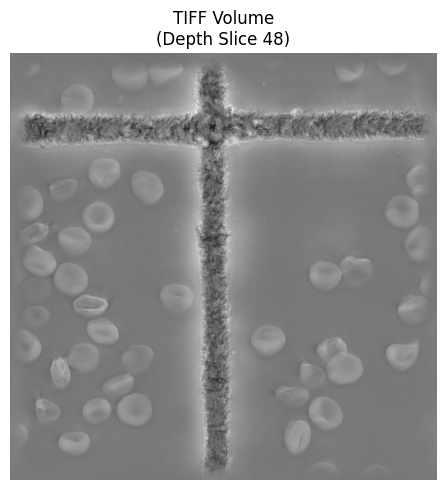

In [ ]:
# Example: Loading a TIFF volume into a PyTorch Tensor
# Use tiff2torch to read single or multi-page TIFFs as tensors.
import matplotlib.pyplot as plt

print("--- Example: tiff2torch ---")

try:
    # Load the real TIFF volume from the data_examples folder
    # This file has a shape of [96, 512, 512] (Depth, Height, Width)
    tensor_img = tiff2torch("./data_examples/example_tiff.tiff")
    print(f"Loaded Tensor Shape: {tensor_img.shape} | Type: {type(tensor_img).__name__}")
    
    # VISUALIZATION (Mid-slice of the volume)
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    
    # Extract slice 48 (middle of the Z axis)
    mid_slice = tensor_img[48].numpy()
    
    ax.imshow(mid_slice, cmap='gray')
    ax.set_title("TIFF Volume\n(Depth Slice 48)")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

In [ ]:
#| hide
from fastcore.test import test_eq
from unittest.mock import patch
import numpy as np
import torch

# Test tiff2torch reading and tensor conversion
def test_tiff2torch():
    # Mocking tifffile to avoid requiring the real file during CI testing
    with patch('tifffile.imread', return_value=np.ones((1, 512, 512))):
        res_tensor = tiff2torch("./data_examples/example_tiff.tiff")
        test_eq(isinstance(res_tensor, torch.Tensor), True)
        test_eq(res_tensor.shape[-2:], (512, 512))
    return "tiff2torch tests passed"

test_eq(test_tiff2torch(), "tiff2torch tests passed")

#### `tiff2torch` Parameter Reference

A lightweight utility function to directly load standard TIFF files into PyTorch tensors using the `tifffile` backend. This is highly useful for bypassing complex medical loaders when you strictly need raw array access to a standard microscope image.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`file_path`** | `str` | The absolute or relative physical path to the `.tiff` or `.tif` file on disk. |

In [ ]:
#| export
def string2dict(s: str) -> dict[str, int | slice | None]:
    """
    Parse layout strings with:
        - sizes: C2
        - slices: Y[100:200]
        - steps:  Y[100:200:2]

    Returns:
        dict[str, int | slice | None]
    """

    result = {}

    pattern = re.findall(
        r"([A-Za-z])"               # axis
        r"(\d+)?"                   # optional size
        r"(?:\[(\d*):(\d*):?(\d*)\])?",  # optional slice w/ step
        s
    )

    for axis, size, start, stop, step in pattern:
        axis = axis.upper()

        # -------------------------
        # slice case
        # -------------------------
        if start or stop or step:
            slc = slice(
                int(start) if start else None,
                int(stop) if stop else None,
                int(step) if step else None,
            )
            result[axis] = slc

        # -------------------------
        # size case
        # -------------------------
        elif size:
            result[axis] = int(size)

        # -------------------------
        # empty axis
        # -------------------------
        else:
            result[axis] = None

    return result

In [ ]:
show_doc(string2dict)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L83){target="_blank" style="float:right; font-size:smaller"}

### string2dict

```python

def string2dict(
    s:str
)->dict:


```

*Parse layout strings with:*
    - sizes: C2
    - slices: Y[100:200]
    - steps:  Y[100:200:2]

Returns:
    dict[str, int | slice | None]

In [ ]:
# Example: Parsing Dimension Strings
print("--- Example: string2dict ---")

# Convert complex string layouts (including sizes and slices) into a Python dictionary.
# This is highly useful for defining specific ROIs (Regions of Interest) in a single string.

# Parse an axis 'X' with a slice, axis 'Z' at index 0, and axis 'C' with size 2
parsed_dims = string2dict("X[10:20:2]Z0C2")

print(f"Input String: 'X[10:20:2]Z0C2'")
print(f"Parsed Dictionary: {parsed_dims}")

--- Example: string2dict ---
Input String: 'X[10:20:2]Z0C2'
Parsed Dictionary: {'X': slice(10, 20, 2), 'Z': 0, 'C': 2}


In [ ]:
#| hide
from fastcore.test import test_eq

# Verify string to dictionary parsing for axes, slices, and exact indices
def test_string2dict():
    res_dict = string2dict("X[10:20:2]Z0C2")
    
    test_eq(res_dict['X'], slice(10, 20, 2))
    test_eq(res_dict['Z'], 0)
    test_eq(res_dict['C'], 2)
    
    # Verify behavior with empty brackets/missing steps
    res_empty = string2dict("Y[:100]T")
    test_eq(res_empty['Y'], slice(None, 100, None))
    test_eq(res_empty['T'], None)
    
    return "string2dict tests passed"

test_eq(test_string2dict(), "string2dict tests passed")

#### `string2dict` Parameter Reference

Parses complex layout strings containing dimension sizes, specific indices, and slice notation, converting them into a native Python dictionary. This allows users to define precise bounding boxes or channel selections directly within configuration files or path strings.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`s`** | `str` | The layout string to parse. Supports exact indices (`"Z0"`), sizes (`"C2"`), and Python-style slices (`"X[10:20:2]"`). |

In [ ]:
#| export
def split_path(file_path, # The path to the file to split
                   exts:(L, list)=['.ome.tiff', '.tiff', '.tif', '.png'] # List of filename extensions 
                   ):
    img_ext = [ext for ext in exts if ext in file_path]
    if img_ext == []:
        return file_path, dict()
    p = file_path.split(img_ext[0])
    if len(p) == 1 or p[1] == '':
        return file_path, dict()
    else:
        path = p[0] + img_ext[0]
        ind_dict = string2dict(p[1])
    return path, ind_dict

In [ ]:
show_doc(split_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L132){target="_blank" style="float:right; font-size:smaller"}

### split_path

```python

def split_path(
    file_path, # The path to the file to split
    exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.ome.tiff', '.tiff', '.tif', '.png'], # List of filename extensions
):


```

In [ ]:
# Example: Path Splitting with Embedded Layouts
print("--- Example: split_path ---")

# split_path extracts the base file path and decodes embedded slice dictionaries.
# This allows passing specific slices or regions of interest as part of the file path itself.

complex_path = "./data_examples/example_tiff.tiff/X[10:20:2]Z0"
clean_path, slice_dict = split_path(complex_path)

print(f"Original Complex Path: {complex_path}")
print(f"Extracted Base Path: {clean_path}")
print(f"Parsed Slices/Indices: {slice_dict}")

--- Example: split_path ---
Original Complex Path: ./data_examples/example_tiff.tiff/X[10:20:2]Z0
Extracted Base Path: ./data_examples/example_tiff.tiff
Parsed Slices/Indices: {'X': slice(10, 20, 2), 'Z': 0}


In [ ]:
#| hide
from fastcore.test import test_eq

# Verify path splitting and dictionary conversion
def test_split_path():
    path, ind = split_path('./data_examples/example_tiff.tiff/X[10:20:2]Z0')
    test_eq(path, './data_examples/example_tiff.tiff')
    test_eq(ind['X'], slice(10, 20, 2))
    test_eq(ind['Z'], 0)
    
    # Test fallback for standard paths without slices
    path_clean, ind_clean = split_path('./data_examples/cameraman_clean.png')
    test_eq(path_clean, './data_examples/cameraman_clean.png')
    test_eq(ind_clean, {})
    
    return "split_path tests passed"

test_eq(test_split_path(), "split_path tests passed")

#### `split_path` Parameter Reference

Separates a valid file path from any appended indexing or slicing instructions (e.g., `image.tiff/C0Z[10:20]`). It returns the clean physical path for the file loader and a dictionary of instructions for the tensor slicer.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`file_path`** | `str` | The full string containing both the file path and the optional layout instructions appended at the end. |
| **`exts`** | `list` | A list of valid file extensions used as delimiters to know where the physical path ends and the instructions begin (default includes common formats like `.ome.tiff`, `.png`, etc.). |

In [ ]:
#| export
def is_ome_tiff(path: Path) -> bool:
    return path.suffixes[-2:] == [".ome", ".tiff"]

In [ ]:
show_doc(is_ome_tiff)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L147){target="_blank" style="float:right; font-size:smaller"}

### is_ome_tiff

```python

def is_ome_tiff(
    path:Path
)->bool:


```

In [ ]:
# Example: Format Detection (OME-TIFF)
from pathlib import Path

print("--- Example: is_ome_tiff ---")

# Check if a given file path strictly corresponds to the OME-TIFF format.

# 1. Check a standard TIFF
path_standard = Path("./data_examples/example_tiff.tiff")
print(f"File: '{path_standard.name}'\nIs OME-TIFF? {is_ome_tiff(path_standard)}\n")

# 2. Check a real OME-TIFF from the dataset
path_ome = Path("./data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff")
print(f"File: '{path_ome.name}'\nIs OME-TIFF? {is_ome_tiff(path_ome)}")

--- Example: is_ome_tiff ---
File: 'example_tiff.tiff'
Is OME-TIFF? False

File: '2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'
Is OME-TIFF? True


In [ ]:
#| hide
from fastcore.test import test_eq
from pathlib import Path

# Verify accurate detection of .ome.tiff suffixes
def test_is_ome_tiff():
    # True cases
    test_eq(is_ome_tiff(Path('./data_examples/sample.ome.tiff')), True)
    
    # False cases
    test_eq(is_ome_tiff(Path('./data_examples/example_tiff.tiff')), False)
    test_eq(is_ome_tiff(Path('./data_examples/cameraman_clean.png')), False)
    
    return "is_ome_tiff tests passed"

test_eq(test_is_ome_tiff(), "is_ome_tiff tests passed")

#### `is_ome_tiff` Parameter Reference

A simple utility to verify if a given file path corresponds to the OME-TIFF format by evaluating its suffixes. This is critical because OME-TIFFs often require a different internal backend reader (`bioio-ome-tiff`) compared to standard TIFFs.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`path`** | `Path` | A `pathlib.Path` object pointing to the file to be evaluated. |

In [ ]:
#| export
from google_crc32c import value


def _to_serializable(value):
    """
    Expand metadata-like objects into dictionaries recursively.
    """
    if isinstance(value, BioImageMetadata):
        return value.to_dict()

    # numpy scalar types
    if isinstance(value, np.generic):
        return value.item()
    
    # primitives
    if isinstance(value, (str, int, float, bool, type(None))):
        return value

    # arrays
    if isinstance(value, (np.ndarray, xr.DataArray)):
        return "<array skipped>"

    # dicts
    if isinstance(value, dict):
        return {
            k: _to_serializable(v)
            for k, v in value.items()
        }

    # lists / tuples
    if isinstance(value, (list, tuple)):
        return [_to_serializable(v) for v in value]

    # objects with __dict__
    if hasattr(value, "__dict__"):
        return {
            k: _to_serializable(v)
            for k, v in vars(value).items()
            if not k.startswith("_")
        }

    # attrs/dataclass-like objects
    if hasattr(value, "__slots__"):
        return {
            k: _to_serializable(getattr(value, k))
            for k in value.__slots__
            if hasattr(value, k)
        }

    # fallback
    return str(value)


def _safe_attr(obj, attr, default=None):
    try:
        return getattr(obj, attr)
    except Exception:
        return default


@dataclass(slots=True)
class BioImageMetadata:
    """
    Lightweight metadata summary for BioIO-backed images.
    """
    filepath: str | None = None
    reader: str | None = None
    dims: str | None = None
    source_shape: tuple[int, ...] | None = None
    dtype: str | None = None
    physical_pixel_sizes: dict | None = None
    scenes: tuple[str, ...] | None = None
    current_scene: str | None = None
    channel_names: tuple[str, ...] | None = None
    layout: str | None = None
    standard_fields: dict = field(default_factory=dict)
    raw: dict = field(default_factory=dict)

    @classmethod
    def from_bioimage(cls, image, path=None, layout=None, raw=None):
        shape = _safe_attr(image, "shape")
        scenes = _safe_attr(image, "scenes")
        channel_names = _safe_attr(image, "channel_names")
        physical_pixel_sizes = _safe_attr(image, "physical_pixel_sizes")
        standard_metadata = _to_serializable(_safe_attr(image, "standard_metadata"))
        reader = _safe_attr(image, "reader")

        return cls(
            filepath=None if path is None else str(path),
            reader=None if reader is None else reader.__class__.__name__,
            dims=str(_safe_attr(image, "dims")),
            source_shape=None if shape is None else tuple(int(v) for v in shape),
            dtype=str(_safe_attr(image, "dtype")),
            physical_pixel_sizes=_to_serializable(physical_pixel_sizes),
            scenes=None if scenes is None else tuple(str(s) for s in scenes),
            current_scene=_to_serializable(_safe_attr(image, "current_scene")),
            channel_names=None if channel_names is None else tuple(str(c) for c in channel_names),
            layout=layout,
            standard_fields={} if not isinstance(standard_metadata, dict) else standard_metadata,
            raw={} if raw is None else raw,
        )

    def to_dict(self, include_raw: bool = False) -> dict:
        meta = asdict(self)
        raw = meta.pop("raw", {})
        standard_fields = meta.pop("standard_fields", {})
        meta = {
            k: _to_serializable(v)
            for k, v in meta.items()
            if v is not None
        }
        meta.update({
            k: _to_serializable(v)
            for k, v in standard_fields.items()
            if v is not None and k not in meta
        })
        if include_raw and raw:
            meta["bioio"] = _to_serializable(raw)
        return meta


def get_aics_metadata(obj, skip=None):
    """
    Return expanded metadata dictionary from an AICSImage object.

    This is intentionally opt-in because walking all BioIO attributes can force
    expensive lazy properties. Use BioImageMetadata for the fast default path.
    """

    default_skip = {
        "data",
        "dask_data",
        "xarray_data",
        "xarray_dask_data",
    }

    if skip is not None:
        default_skip.update(skip)

    attrs = {}

    for attr in dir(obj):

        if attr.startswith("_"):
            continue

        if attr in default_skip:
            continue

        try:
            value = getattr(obj, attr)

            # skip methods/functions
            if callable(value):
                continue

            attrs[attr] = _to_serializable(value)

        except Exception as e:
            attrs[attr] = f"<error: {e}>"

    return attrs


def _bioio_metadata(image, path=None, layout=None, metadata="summary", skip=None):
    """
    Build BioIO metadata without forcing expensive lazy attributes by default.
    """
    if metadata in (False, None, "none"):
        return {}

    if isinstance(metadata, BioImageMetadata):
        return metadata.to_dict()

    if metadata in (True, "full"):
        raw = get_aics_metadata(image, skip=skip)
        return BioImageMetadata.from_bioimage(
            image,
            path=path,
            layout=layout,
            raw=raw,
        ).to_dict(include_raw=True)

    return BioImageMetadata.from_bioimage(
        image,
        path=path,
        layout=layout,
    ).to_dict()


In [ ]:
show_doc(BioImageMetadata)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L212){target="_blank" style="float:right; font-size:smaller"}

### BioImageMetadata

```python

def BioImageMetadata(
    filepath:str | None=None, reader:str | None=None, dims:str | None=None, source_shape:tuple[int, ...] | None=None,
    dtype:str | None=None, physical_pixel_sizes:dict | None=None, scenes:tuple[str, ...] | None=None,
    current_scene:str | None=None, channel_names:tuple[str, ...] | None=None, layout:str | None=None,
    standard_fields:dict=<factory>, raw:dict=<factory>
)->None:


```

*Lightweight metadata summary for BioIO-backed images.*

In [ ]:
show_doc(get_aics_metadata)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L272){target="_blank" style="float:right; font-size:smaller"}

### get_aics_metadata

```python

def get_aics_metadata(
    obj, skip:NoneType=None
):


```

*Return expanded metadata dictionary from an AICSImage object.*

This is intentionally opt-in because walking all BioIO attributes can force
expensive lazy properties. Use BioImageMetadata for the fast default path.

In [ ]:
# Example: Extracting metadata with the public API
import warnings
from bioio import BioImage as AICSImage

print("--- Example: Metadata Extraction (Summary vs Full) ---")

try:
    # Suppress harmless warnings from bioio readers for clean documentation output
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # Load the image object (does not load the full array into memory yet)
        aics_img = AICSImage('./data_examples/example_tiff.tiff')

        # 1. Lightweight metadata summary using the public dataclass (Fast)
        meta_summary = BioImageMetadata.from_bioimage(aics_img, path='./data_examples/example_tiff.tiff', layout="CZYX")
        summary_dict = meta_summary.to_dict()
        print(f"Summary generated instantly. Main keys:")
        print(f"  {list(summary_dict.keys())[:5]}...\n")

        # 2. Full extraction of all attributes (Opt-in, slower as it may trigger lazy properties)
        full_meta = get_aics_metadata(aics_img)
        print(f"Full metadata generated. Total attributes extracted: {len(full_meta)}")
        print(f"Contains 'dims'?: {'dims' in full_meta}")
except Exception as e:
    print(f"Example skipped (test file missing or error): {e}")

Attempted file (/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


--- Example: Metadata Extraction (Summary vs Full) ---
Summary generated instantly. Main keys:
  ['filepath', 'reader', 'dims', 'source_shape', 'dtype']...

Full metadata generated. Total attributes extracted: 19
Contains 'dims'?: True


In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

def test_metadata_utils():
    # Test _to_serializable with different data types
    test_eq(_to_serializable(np.int64(42)), 42)
    test_eq(_to_serializable(np.array([1, 2, 3])), "<array skipped>")
    test_eq(_to_serializable({"a": np.float32(1.5)}), {"a": 1.5})

    aics_img = AICSImage('./data_examples/example_tiff.tiff')

    # Test fast metadata extraction
    summary_meta = _bioio_metadata(aics_img, './data_examples/example_tiff.tiff', layout="CZYX")
    test_eq(isinstance(summary_meta, dict), True)
    test_eq(summary_meta['layout'], "CZYX")
    test_eq('source_shape' in summary_meta, True)
    test_eq('shape' in summary_meta, False)
    test_eq('standard_metadata' in summary_meta, False)
    test_eq('image_size_x' in summary_meta, True)

    # Test full get_aics_metadata extraction remains available when explicitly requested
    meta_dict = get_aics_metadata(aics_img)
    test_eq(isinstance(meta_dict, dict), True)
    test_eq('dims' in meta_dict, True)
    test_eq('dtype' in meta_dict, True)
    
    return "Metadata utils tests passed"

test_eq(test_metadata_utils(), "Metadata utils tests passed")

Attempted file (/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0
/home/export/personal/miguel/anaconda3/envs/biomonai_latest/lib/python3.11/site-packages/bioio_tifffile/reader.py:164: UserWarning: Could not parse tiff pixel size: 'ResolutionUnit'
  warnings.warn(f"Could not parse tiff pixel size: {e}")


#### `BioImageMetadata` Class Attributes & Parameter Reference

A lightweight dataclass that summarizes metadata extracted from BioIO/AICSImage objects. It provides a fast, standardized summary of the image properties without triggering expensive lazy loading operations that reading the full metadata tree might cause.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`filepath`** | `str` / `None` | The path to the loaded image file. |
| **`reader`** | `str` / `None` | The name of the BioIO reader class used to parse the file. |
| **`dims`** | `str` / `None` | The dimensional axes present in the image (e.g., `'TCZYX'`). |
| **`source_shape`** | `tuple` / `None` | The original shape of the data array as read from the file. |
| **`dtype`** | `str` / `None` | The data type of the image array (e.g., `uint16`, `float32`). |
| **`physical_pixel_sizes`** | `dict` / `None` | Dictionary containing the physical dimensions (X, Y, Z) of the pixels/voxels. |
| **`scenes`** | `tuple` / `None` | Available scenes/series within the file (common in `.czi` or `.ome.tiff`). |
| **`current_scene`** | `str` / `None` | The currently active scene being read. |
| **`channel_names`** | `tuple` / `None` | Names of the specific channels present in the image. |
| **`layout`** | `str` / `None` | The target channel layout requested during loading (e.g., `'CZYX'`). |
| **`standard_fields`** | `dict` | Additional standard metadata automatically parsed by the reader. |
| **`raw`** | `dict` | The full, unparsed raw metadata (populated only if explicitly requested). |

---

#### `get_aics_metadata` Parameter Reference

Extracts the full, expanded metadata dictionary from an `AICSImage` object. This is an opt-in function because traversing all BioIO attributes deeply may force the evaluation of expensive lazy properties. Use `BioImageMetadata` for the fast default path unless you specifically need the raw nested tags.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`obj`** | `AICSImage` | The instantiated BioIO/AICSImage object to extract metadata from. |
| **`skip`** | `set` / `None` | A set of attribute strings to skip during extraction (defaults to skipping heavy array-like attributes such as `data`, `dask_data`, `xarray_data`). |

In [ ]:
#| export

def extract_formats(filenames: Sequence[str] | str) -> list[str | None]:
    """
    Extract file format(s) from one or multiple filenames.

    Supports:
        - standard extensions (.nii.gz, .png, .npz)
        - HDF5 internal paths (.hdf5/... or .h5/...)

    Args:
        filenames: single path or sequence of paths.

    Returns:
        List of format strings in uppercase (without dots),
        or None if no suffix is found.
    """

    if isinstance(filenames, (str, Path)):
        filenames = [filenames]

    formats = []

    for name in filenames:
        path_str = str(name).lower()

        # HDF5 special case
        if any(ext in path_str for ext in (".h5", ".hdf5")):
            formats.append("HDF5")
            continue

        # Standard suffixes
        suffixes = Path(name).suffixes
        if suffixes:
            fmt = "".join(suffixes).lstrip(".").upper()
            formats.append(fmt)
        else:
            formats.append(None)

    return formats

In [ ]:
show_doc(extract_formats)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L342){target="_blank" style="float:right; font-size:smaller"}

### extract_formats

```python

def extract_formats(
    filenames:collections.abc.Sequence[str] | str
)->list:


```

*Extract file format(s) from one or multiple filenames.*

Supports:
    - standard extensions (.nii.gz, .png, .npz)
    - HDF5 internal paths (.hdf5/... or .h5/...)

Args:
    filenames: single path or sequence of paths.

Returns:
    List of format strings in uppercase (without dots),
    or None if no suffix is found.

In [ ]:
# Example: Extracting formats from file paths
print("--- Example: extract_formats ---")

# This utility handles single strings, lists of files, and complex HDF5 internal paths,
# returning standardized uppercase format strings.

# 1. Extract from a single file path
single_format = extract_formats("scan.nii.gz")
print(f"Single file format: {single_format}")

# 2. Extract from a list of various paths (including internal HDF5 paths)
multi_paths = [
    "image.png", 
    "data.npz", 
    "./data_examples/0450_1.hdf5/clean/10"
]
multi_formats = extract_formats(multi_paths)
print(f"Multiple formats detected: {multi_formats}")

--- Example: extract_formats ---
Single file format: ['NII.GZ']
Multiple formats detected: ['PNG', 'NPZ', 'HDF5']


In [ ]:
#| hide
from fastcore.test import test_eq

def test_extract_formats():
    # Test extract_formats with different extensions and paths
    test_eq(extract_formats('image.png'), ['PNG'])
    test_eq(extract_formats(['test.nii.gz', 'data.npz']), ['NII.GZ', 'NPZ'])
    test_eq(extract_formats('./data_examples/0450_1.hdf5/clean/10'), ['HDF5'])
    
    return "extract_formats tests passed"

test_eq(test_extract_formats(), "extract_formats tests passed")

#### `extract_formats` Parameter Reference

Extracts and standardizes file format extensions from one or multiple file paths. It includes special handling for HDF5 paths where the physical file extension might be followed by an internal dataset path or index, ensuring the format is still correctly identified.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`filenames`** | `Sequence[str]` / `str` | A single file path string or a sequence (list/tuple) of file paths from which to extract the formats. |

In [ ]:
#| export
def _sanitize(obj):
    """
    Convert non-serializable objects into safe representations
    and recursively extract nested transform parameters.
    """

    # dictionaries
    if isinstance(obj, dict):
        return {k: _sanitize(v) for k, v in obj.items()}

    # lists / tuples
    elif isinstance(obj, (list, tuple)):
        return type(obj)(_sanitize(v) for v in obj)

    # classes/types
    elif isinstance(obj, type):
        return obj.__name__

    # numpy dtypes
    elif isinstance(obj, np.dtype):
        return str(obj)

    # nested objects / transforms
    elif hasattr(obj, "__dict__") and not isinstance(obj, (str, int, float, bool)):
        return {
            "__class__": obj.__class__.__name__,
            **{
                k: _sanitize(v)
                for k, v in vars(obj).items()
                if not k.startswith("_")
            },
        }

    # callables
    elif callable(obj):
        return obj.__name__ if hasattr(obj, "__name__") else str(obj)

    # everything else
    else:
        return obj

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

def test_sanitize():
    # Test _sanitize with type, numpy dtype, and callable
    def dummy_function(): pass

    sample_obj = {
        "class_type": int,
        "numpy_dtype": np.dtype('float32'),
        "callable_fn": dummy_function
    }

    res_sanitized = _sanitize(sample_obj)
    test_eq(res_sanitized['class_type'], 'int')
    test_eq(res_sanitized['numpy_dtype'], 'float32')
    test_eq(res_sanitized['callable_fn'], {'__class__': 'function'})
    
    return "_sanitize tests passed"

test_eq(test_sanitize(), "_sanitize tests passed")

### BioIO Formats
> Universal biological image loading engine powered by the AICSImageIO (`bioio`) ecosystem, designed to handle complex multidimensional formats like CZI, OME-TIFF, and standard TIFFs.

* **`bioio_loader`**: A robust wrapper class that parses biological image files, extracting the raw data tensor, its spatial affine matrix, and a lightweight metadata dictionary in a single, standardized call. It supports on-the-fly dimension formatting and slicing.

In [ ]:
#| export
class bioio_loader():
    
    def __init__(self,
                 ind_dict=None, # Dictionary indicating the channels to load
                 loader=None, # Optional custom reader to use for loading the image
                 channels="CZYX", # The desired channel order for the output data
                 metadata: str | bool | BioImageMetadata = "summary", # Metadata mode: "summary", "full", or "none"
                 metadata_skip: set[str] | None = None, # Extra full-metadata fields to skip
                 **kwargs,
                ):
        store_attr()
        self.kwargs = kwargs

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The file path to the image             
               ):

        """
        Loads an image from the specified path using AICSImage library.

        Parameters:
            path (str): The file path to the image.

        Returns:
            tuple: A tuple containing the image data and its affine transformation matrix.
                The image data is a NumPy array representing the image.
                The affine transformation matrix is a 4x4 NumPy array.
        """

        ind_dict = self.ind_dict
        if ind_dict == None:
            # parse path string
            path, ind_dict = split_path(str(path))
             
        path = str(path)
        self.kwargs.setdefault('reconstruct_mosaic', False)
        image_aics = AICSImage(path, reader=self.loader, **self.kwargs)

        # Convert to numpy array    
        data = image_aics.get_image_data(self.channels, **ind_dict)
        # extract lightweight metadata by default
        meta = _bioio_metadata(
            image_aics,
            path=path,
            layout=self.channels,
            metadata=self.metadata,
            skip=self.metadata_skip,
        )
        # Create an identity affine transformation matrix
        affine = np.eye(4)
        # Return the image data and the affine matrix
        return data, meta, affine



In [ ]:
show_doc(bioio_loader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L424){target="_blank" style="float:right; font-size:smaller"}

### bioio_loader

```python

def bioio_loader(
    ind_dict:NoneType=None, # Dictionary indicating the channels to load
    loader:NoneType=None, # Optional custom reader to use for loading the image
    channels:str='CZYX', # The desired channel order for the output data
    metadata:str | bool | __main__.BioImageMetadata='summary', # Metadata mode: "summary", "full", or "none"
    metadata_skip:set[str] | None=None, # Extra full-metadata fields to skip
    kwargs:VAR_KEYWORD
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

--- Example: bioio_loader (BioIO Integration) ---


Attempted file (/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/export/personal/miguel/git_projects/bioMONAI/nbs/data_examples/example_tiff.tiff'. Failed to parse XML for the provided file. Error: no element found: line 1, column 0


Loaded Data Shape: (1, 5, 512, 512)
Affine Matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

MetaTensor created successfully!
Metadata keys: ['filepath', 'reader', 'dims', 'source_shape', 'dtype']...


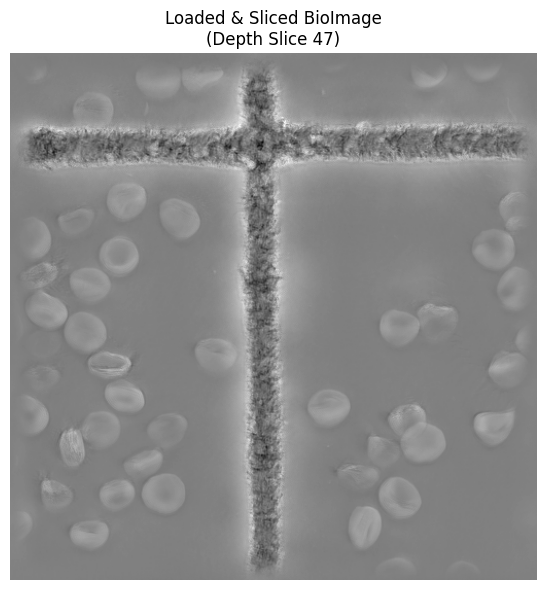

In [ ]:
# Example: Loading images with bioio_loader
import matplotlib.pyplot as plt
import warnings
from monai.data import MetaTensor

print("--- Example: bioio_loader (BioIO Integration) ---")

# bioio_loader integrates with AICSImage to extract the data tensor, metadata, 
# and affine matrix directly from complex biological formats.

try:
    # 1. Initialize the loader, specifying a slice dictionary and channel layout
    # We slice the 'Z' axis to extract just 5 slices to save memory during loading
    loader = bioio_loader(ind_dict={'Z': slice(45, 50)}, channels="CZYX")
    
    # 2. Load the biological image from a real path
    file_path = './data_examples/example_tiff.tiff'
    
    # Suppress warnings from bioio_tifffile missing resolution tags
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        img_data, meta, affine = loader(file_path)
    
    print(f"Loaded Data Shape: {img_data.shape}")
    print(f"Affine Matrix:\n{affine}\n")
    
    # 3. Seamlessly integrate with MONAI's MetaTensor
    img_tensor = MetaTensor(x=img_data, affine=affine, meta=meta)
    print(f"MetaTensor created successfully!")
    print(f"Metadata keys: {list(img_tensor.meta.keys())[:5]}...")
    
    # VISUALIZATION
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    # img_data shape is (C, Z, Y, X) -> (1, 5, 512, 512). Let's plot the middle slice (index 2)
    ax.imshow(img_data[0, 2], cmap='gray')
    ax.set_title("Loaded & Sliced BioImage\n(Depth Slice 47)")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Visualization skipped: {e}")

In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np
import torch
import warnings
from monai.data import MetaTensor
from bioio_tifffile import Reader as TiffReader

def test_bioio_loader_and_metatensor():
    # --- Test 1: bioio_loader ---
    file_path = './data_examples/example_tiff.tiff'
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Load only 10 slices from the Z-axis, forcing TiffReader
        test_img, meta, affine = bioio_loader({'Z': slice(0, 10)}, channels="CZYX", loader=TiffReader)(file_path)

    test_eq(test_img.shape, (1, 10, 512, 512))
    test_eq(isinstance(meta, dict), True)
    test_eq(affine.shape, (4, 4))

    # --- Test 2: MetaTensor integration with loaded data ---
    a = MetaTensor(x=test_img, affine=affine, meta=meta)

    # Using torch.Tensor to ensure compatibility with MetaTensor's internal affine type
    test_eq(a.affine, torch.Tensor(np.eye(4)))
    test_eq(isinstance(a.detach().cpu().numpy(), np.ndarray), True)
    test_eq(isinstance(a.meta, dict), True)
    
    return "bioio_loader tests passed"

test_eq(test_bioio_loader_and_metatensor(), "bioio_loader tests passed")

#### `bioio_loader` Class Attributes & Parameter Reference

A robust loader class that acts as a wrapper around the `bioio` (AICSImageIO) ecosystem. It seamlessly handles the reading of complex multidimensional biological formats (like CZI or OME-TIFF) and returns standard data arrays accompanied by spatial affine matrices and lightweight metadata dictionaries.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`ind_dict`** | `dict` / `None` | Dictionary specifying spatial or channel slicing (e.g., `{'C': 0, 'Z': slice(10, 20)}`). Overrides slices provided directly in the path string. |
| **`loader`** | `Callable` / `None` | Optional custom BioIO reader class to enforce a specific parsing backend. If `None`, the format is auto-detected. |
| **`channels`** | `str` | The desired dimensional layout of the output tensor (default: `'CZYX'`). Missing dimensions are added automatically. |
| **`metadata`** | `str` / `bool` | Determines the metadata extraction depth. Options: `"summary"` (default), `"full"`, or `"none"`. |
| **`metadata_skip`** | `set` / `None` | A set of string identifiers defining which expensive attributes to bypass when `metadata="full"` is used. |
| **`**kwargs`** | `dict` | Additional keyword arguments passed directly down to the underlying `AICSImage` backend reader. |

### Hierarchical Data Format
> Utilities and loaders specifically designed to interact with HDF5 files, allowing seamless extraction of internal datasets and patches.

* **`split_hdf_path`**: Parses compound strings that encode both the physical HDF5 file path and the internal dataset/patch location.
* **`hdf5_loader`**: A specialized loader for reading image patches and arrays from hierarchical HDF5 files, supporting on-the-fly dimension padding and metadata extraction.

In [ ]:
#| export
def split_hdf_path(file_path, # The path to the HDF5 file to split
                   hdf5_exts:(L, list)=['.h5','.hdf5'] # List of filename extensions 
                   ):
    hdf5_ext = [ext for ext in hdf5_exts if ext in file_path][0]
    if hdf5_ext == []:
        return file_path, None, None
    p = file_path.split(hdf5_ext)
    if len(p) == 1 or p[1] == '':
        return file_path, None, None
    else:
        path = p[0] + hdf5_ext
        tmp = p[1].split('/')[1:]
        dataset = os.path.join(*tmp[:-1])
        patch = tmp[-1]
    return path, dataset, patch

In [ ]:
show_doc(split_hdf_path)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L483){target="_blank" style="float:right; font-size:smaller"}

### split_hdf_path

```python

def split_hdf_path(
    file_path, # The path to the HDF5 file to split
    hdf5_exts:(<class 'fastcore.foundation.L'>, <class 'list'>)=['.h5', '.hdf5'], # List of filename extensions
):


```

In [ ]:
# Example: Parsing HDF5 compound paths
print("--- Example: split_hdf_path (HDF5 Path Parsing) ---")

# split_hdf_path extracts the base file path, the internal dataset name, 
# and the patch/index from a single string. This is very useful when defining 
# specific HDF5 locations directly in a CSV or dataframe.

complex_hdf5_path = "data_examples/0450_1.hdf5/clean/10"
base_path, dataset, patch = split_hdf_path(complex_hdf5_path)

print(f"Raw Input Path: {complex_hdf5_path}")
print(f"Base Path:      {base_path}")
print(f"Dataset:        {dataset}")
print(f"Patch/Index:    {patch}")

--- Example: split_hdf_path (HDF5 Path Parsing) ---
Raw Input Path: data_examples/0450_1.hdf5/clean/10
Base Path:      data_examples/0450_1.hdf5
Dataset:        clean
Patch/Index:    10


In [ ]:
#| hide
from fastcore.test import test_eq

def test_split_hdf_path():
    # Test split_hdf_path with compound paths
    h_path, ds, pt = split_hdf_path('data_examples/0450_1.hdf5/clean/10')
    test_eq(h_path, 'data_examples/0450_1.hdf5')
    test_eq(ds, 'clean')
    test_eq(pt, '10')

    # Test split_hdf_path with standard paths (no internal dataset specified)
    h_path2, ds2, pt2 = split_hdf_path('data_examples/0450_1.hdf5')
    test_eq(h_path2, 'data_examples/0450_1.hdf5')
    test_eq(ds2, None)
    test_eq(pt2, None)
    
    return "split_hdf_path tests passed"

test_eq(test_split_hdf_path(), "split_hdf_path tests passed")

#### `split_hdf_path` Parameter Reference

Separates a compound string into the physical HDF5 file path, the internal dataset name, and the specific patch or index. This allows users to store precise pointers to data within an HDF5 hierarchy as flat strings in CSVs or DataFrames.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`file_path`** | `str` | The compound string to split (e.g., `'dataset.h5/internal_folder/patch_01'`). |
| **`hdf5_exts`** | `list` | A list of valid file extensions used as the delimiter to split the string (default: `['.h5', '.hdf5']`). |

In [ ]:
#| export
class hdf5_loader():
    def __init__(self,
                 dataset: Optional[str]=None, # The dataset to load
                 patch: Optional[str]=None, # The patch to load from the dataset
                 hdf5_exts: List[str]=['.h5','.hdf5'], # List of filename extensions 
                 channels: str="CYX" # The desired channel layout for the output data
                ):
        store_attr()

    def __call__(self, path) -> Any:
        return self.image_reader(path)
    
    def image_reader(self, 
               path, # The path to the HDF5 file to be read
               ):
        """
        Reads a *.h5 (HDF5 format) file and returns the image data along with an identity affine matrix.

        Parameters:
        path (str): The path to the file to be read.

        Returns:
        tuple: A tuple containing:
            - data (numpy.ndarray): The image data read from the file.
            - affine (numpy.ndarray): A 4x4 identity affine matrix.
        """
        
        # split path
        if self.dataset == None:
            path, dataset, patch = split_hdf_path(path, self.hdf5_exts)
            self.dataset = dataset
            self.patch = patch

        with h5py.File(path, 'r') as file:
                if self.dataset == None: print('List of datasets in this file: \n',list(file.keys())); return None
                else:
                    data = file[self.dataset + '/' + self.patch][:] 
                    meta = dict(file[self.dataset].attrs)
                    if 'patch_location' in file[self.dataset + '/' + self.patch].attrs:
                        meta['patch_location'] = file[self.dataset + '/' + self.patch].attrs['patch_location']

        # adjust data dimensions according to channels layout
        while len(data.shape) < len(self.channels):
            # add absent dimensions assuming missing dimensions are at the beginning
            data = np.expand_dims(data, axis=0)
        if len(data.shape) > len(self.channels):
            # remove absent dimensions assuming that data is in CZYX order and missing dimensions are at the beginning
            data = data[(0,)*(data.ndim - len(self.channels)) + (slice(None),)*len(self.channels)]
                
        # If affine is not in meta dict, create a 4x4 identity affine NumpyArray
        if 'affine' in meta:
            affine = meta['affine']
        else:
            affine = np.eye(4)

        # Return the image data and the affine matrix
        return data, meta, affine


In [ ]:
show_doc(hdf5_loader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L500){target="_blank" style="float:right; font-size:smaller"}

### hdf5_loader

```python

def hdf5_loader(
    dataset:Optional=None, # The dataset to load
    patch:Optional=None, # The patch to load from the dataset
    hdf5_exts:List=['.h5', '.hdf5'], # List of filename extensions
    channels:str='CYX', # The desired channel layout for the output data
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

Images can be loaded by explicitly providing the dataset name and patch number during initialization, or by encoding them directly into the path string (treating datasets as subfolders and patches as files). The latter approach is fully compatible with standard `image_reader` syntax, making it ideal for CSV/DataFrame data pipelines.

--- Example: hdf5_loader ---
Method 1 (Explicit) - Loaded Shape: (1, 96, 96)
Method 2 (Encoded)  - Loaded Shape: (1, 96, 96)
Extracted Metadata keys: []


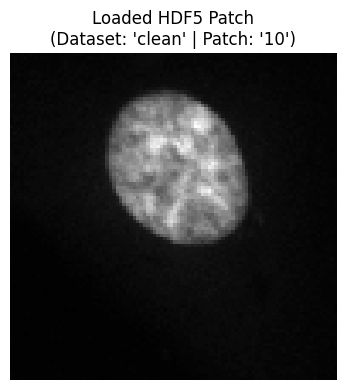

In [ ]:
# Example: HDF5 Image Loading Methods
import matplotlib.pyplot as plt
from monai.data import MetaTensor

print("--- Example: hdf5_loader ---")

# Method 1: Explicit Initialization
file_path = './data_examples/0450_1.hdf5'
dataset_name = 'clean'
patch_num = '10'

loader_explicit = hdf5_loader(dataset=dataset_name, patch=patch_num)
im_explicit, meta_explicit, affine = loader_explicit(file_path)
print(f"Method 1 (Explicit) - Loaded Shape: {im_explicit.shape}")

# Method 2: Encoded Path String
encoded_path = f"{file_path}/{dataset_name}/{patch_num}"
loader_encoded = hdf5_loader()
im_encoded, meta_encoded, _ = loader_encoded(encoded_path)
print(f"Method 2 (Encoded)  - Loaded Shape: {im_encoded.shape}")
print(f"Extracted Metadata keys: {list(meta_encoded.keys())}")

# VISUALIZATION
try:
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    
    # im_encoded shape is (C, Y, X) -> (1, 96, 96). Plotting the single channel.
    ax.imshow(im_encoded[0], cmap='gray')
    ax.set_title("Loaded HDF5 Patch\n(Dataset: 'clean' | Patch: '10')")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visualization skipped: {e}")

In [ ]:
#| hide
from fastcore.test import test_eq

def test_hdf5_loader():
    # Test hdf5_loader with explicit dataset and patch keys
    file_path = './data_examples/0450_1.hdf5'
    dataset_name = 'clean'
    patch_num = '10'

    loader_fn = hdf5_loader(dataset=dataset_name, patch=patch_num)
    im, meta, affine = loader_fn(file_path)

    # Verify loaded shape, metadata dictionary, and 4x4 affine matrix
    test_eq(im.shape, (1, 96, 96))
    test_eq(isinstance(meta, dict), True)
    test_eq(affine.shape, (4, 4))
    
    # Test path-encoded method
    f = f"{file_path}/{dataset_name}/{patch_num}"
    im2, meta2, _ = hdf5_loader()(f)
    test_eq(im.shape, im2.shape)
    
    return "hdf5_loader tests passed"

test_eq(test_hdf5_loader(), "hdf5_loader tests passed")

#### `hdf5_loader` Class Attributes & Parameter Reference

A specialized loader for reading image patches and arrays from hierarchical HDF5 files. It automatically handles missing dimensions (padding them to match the target layout) and extracts dataset-level attributes to populate the metadata dictionary.

| Parameter | Type | Description |
| :--- | :--- | :--- |
| **`dataset`** | `str` / `None` | The internal HDF5 dataset name or group to load. Can be omitted if the dataset is embedded directly in the path string. |
| **`patch`** | `str` / `None` | The specific patch index or name within the dataset. Can be omitted if embedded in the path string. |
| **`hdf5_exts`** | `list` | Expected file extensions used to parse compound paths (default: `['.h5', '.hdf5']`). |
| **`channels`** | `str` | The desired target dimension layout for the output tensor (default: `'CYX'`). Missing dimensions are automatically padded. |

### Preprocessing
> Internal mechanisms to manage, track, and record metadata during the execution of data transformation pipelines.

*(This section contains internal utilities used by the loaders to apply transforms and safely serialize execution times and parameters into the image metadata.)*

In [ ]:
#| export
def _as_transform_list(transforms):
    if transforms is None:
        return ()
    if callable(transforms):
        return (transforms,)
    return transforms


def _preprocess(obj, transforms=None):
    transforms = _as_transform_list(transforms)
    meta = obj.meta
    meta['size_loaded'] = obj.shape

    if not transforms:
        meta['size_after_tfms'] = obj.shape
        return obj

    transform_meta = meta.setdefault('transforms', {})

    for t in transforms:
        start = time.perf_counter()
        obj = t(obj)
        elapsed = time.perf_counter() - start

        meta = obj.meta
        if transform_meta is not meta.get('transforms'):
            transform_meta = meta.setdefault('transforms', transform_meta)

        raw_params = getattr(t, "__dict__", None)
        transform_meta[t.__class__.__name__] = {
            'time': elapsed,
            'params': {} if not raw_params else _sanitize(raw_params),
        }

    obj.meta['size_after_tfms'] = getattr(obj, "shape", None)

    return obj


In [ ]:
#| hide
from fastcore.test import test_eq
from monai.transforms import ScaleIntensity
from monai.data import MetaTensor
import numpy as np
import torch

def test_preprocess():
    # Creamos datos ficticios con las mismas dimensiones para aislar el test
    test_img = torch.ones((1, 1, 10, 225))
    affine = torch.eye(4)
    meta = {'dummy_key': 'dummy_value'}
    
    a_copy = MetaTensor(x=test_img, affine=affine, meta=meta.copy())
    
    # Test _preprocess con la transformación ScaleIntensity
    res_processed = _preprocess(a_copy, [ScaleIntensity()])

    # Verificamos los registros de las transformaciones
    test_eq(len(res_processed.meta['transforms']) > 0, True)
    test_eq('ScaleIntensity' in res_processed.meta['transforms'], True)
    
    # Verificamos los tamaños originales y finales cuando no hay transformaciones
    res_unprocessed = _preprocess(a_copy, None)
    test_eq(list(res_unprocessed.meta['size_loaded']), [1, 1, 10, 225])
    
    return "preprocess tests passed"

test_eq(test_preprocess(), "preprocess tests passed")

In [ ]:
#| export
def _preprocess_dict(
    obj: dict,
    transforms: Callable | Iterable[Callable] | None = None,
) -> dict:
    """
    Apply dictionary-based transforms and attach metadata to transformed
    MetaTensor entries.

    This function is designed for MONAI-style dictionary transforms
    (e.g. MapTransform subclasses) that expose a ``keys`` attribute.
    Metadata is stored directly in each transformed MetaTensor under
    ``tensor.meta``.

    Stored metadata includes:
        - ``size_loaded``:
            Shape before preprocessing.
        - ``transforms``:
            Per-transform timing and parameter information.
        - ``size_after_tfms``:
            Final shape after all transforms.

    Args:
        obj:
            Input dictionary containing MetaTensor objects.
        transforms:
            A callable or iterable of callables operating on dictionaries.

    Returns:
        dict:
            Transformed dictionary with updated MetaTensor metadata.
    """
    transforms = _as_transform_list(transforms)
    if not transforms:
        return obj

    processed_keys = set()

    for t in transforms:
        keys = getattr(t, "keys", ())
        name = t.__class__.__name__
        raw_params = getattr(t, "__dict__", None)
        safe_params = {} if not raw_params else _sanitize(raw_params)

        start = time.perf_counter()
        obj = t(obj)
        elapsed = time.perf_counter() - start

        for key in keys:
            tensor = obj.get(key)

            if not isinstance(tensor, MetaTensor):
                continue

            processed_keys.add(key)
            tensor.meta.setdefault("transforms", {})[name] = {
                "time": elapsed,
                "params": safe_params,
            }

    for key in processed_keys:
        tensor = obj[key]

        if isinstance(tensor, MetaTensor):
            tensor.meta["size_after_tfms"] = tensor.shape 

    return obj


In [ ]:
#| hide
from fastcore.test import test_eq
from monai.transforms import ScaleIntensityd
from monai.data import MetaTensor
import torch

def test_preprocess_dict():
    # Create mock data to isolate the test completely
    test_img = torch.ones((1, 1, 10, 225))
    affine = torch.eye(4)
    meta = {'size_loaded': [1, 1, 10, 225]} # Adding expected base metadata
    
    # Test _preprocess_dict using a MONAI dictionary transform
    dict_sample = {"image": MetaTensor(x=test_img, affine=affine, meta=meta.copy())}
    res_dict = _preprocess_dict(dict_sample, [ScaleIntensityd(keys="image")])

    # Verify that metadata and transformed sizes are properly attached
    test_eq("ScaleIntensityd" in res_dict["image"].meta["transforms"], True)
    test_eq(res_dict["image"].meta["size_after_tfms"], res_dict["image"].shape)
    
    return "preprocess_dict tests passed"

test_eq(test_preprocess_dict(), "preprocess_dict tests passed")

### Loaders Registry
> A centralized registry system to dynamically map file extensions to their corresponding specialized image loader functions.

* **`LoaderRegistry`**: A dictionary-backed class that uses decorators to register loading functions to specific file suffixes, enabling automatic format detection and routing.
* **`LOADER_REGISTRY`**: The global instantiated registry used throughout the data loading pipeline.

In [ ]:
#| export

class LoaderRegistry:
    def __init__(self):
        self._loaders = {}

    def register(self, *suffixes):
        def decorator(fn):
            for s in suffixes:
                self._loaders[s.lower()] = fn
            return fn
        return decorator

    def get(self, path: Path):
        full_suffix = "".join(path.suffixes).lower()
        if full_suffix in self._loaders:
            return self._loaders[full_suffix]
        return self._loaders.get(path.suffix.lower())


LOADER_REGISTRY = LoaderRegistry()

In [ ]:
show_doc(LoaderRegistry)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L669){target="_blank" style="float:right; font-size:smaller"}

### LoaderRegistry

```python

def LoaderRegistry(
    
):


```

*Initialize self.  See help(type(self)) for accurate signature.*

In [ ]:
# Example: Registering and retrieving file-specific loaders
from pathlib import Path

print("--- Example: LoaderRegistry ---")

# LoaderRegistry allows you to elegantly map file extensions to custom loading functions.

# 1. Initialize a new registry (for demonstration purposes)
example_registry = LoaderRegistry()

# 2. Register a custom loader for specific extensions using the decorator
@example_registry.register(".custom", ".xyz")
def my_custom_loader(path, **kwargs):
    return f"Success: Data extracted from '{path.name}'"

# 3. Retrieve the correct loader based on the file path
file_path = Path("dataset/scan.custom")
loader_fn = example_registry.get(file_path)

print(f"File evaluated: {file_path}")
if loader_fn:
    result = loader_fn(file_path)
    print(f"Registered Loader Executed -> {result}")
else:
    print("No loader found for this extension.")

--- Example: LoaderRegistry ---
File evaluated: dataset/scan.custom
Registered Loader Executed -> Success: Data extracted from 'scan.custom'


In [ ]:
#| hide
from fastcore.test import test_eq
from pathlib import Path

def test_loader_registry():
    # Test LoaderRegistry registration and retrieval behaviors
    registry_test = LoaderRegistry()

    @registry_test.register(".png", ".jpg")
    def dummy_png_loader(path, **kwargs): return "png_loaded"

    # Verify exact and extension-based fallback matches
    test_eq(registry_test.get(Path("sample.png")), dummy_png_loader)
    test_eq(registry_test.get(Path("sample.jpg")), dummy_png_loader)
    test_eq(registry_test.get(Path("sample.txt")), None)
    
    return "LoaderRegistry tests passed"

test_eq(test_loader_registry(), "LoaderRegistry tests passed")

#### `LoaderRegistry` Class Attributes & Parameter Reference

A lightweight, decorator-based routing mechanism. It evaluates incoming file paths and dispatches them to the appropriate backend loader function based on their file extension (e.g., routing `.nii.gz` to NiBabel, or `.ome.tiff` to BioIO).

| Method / Attribute | Type | Description |
| :--- | :--- | :--- |
| **`_loaders`** | `dict` | Internal dictionary mapping lowercase file suffixes (e.g., `'.png'`) to callable loading functions. |
| **`register(*suffixes)`** | `Callable` | A decorator method that binds a loading function to one or multiple file extensions. |
| **`get(path)`** | `Callable` / `None` | Evaluates a `pathlib.Path` object and returns the matching loader for its suffix, or `None` if unsupported. |

Default loader (AICS only)

In [ ]:
#| export
def _load_default(path, ind_dict=None, loader=None, channels="CZYX", **kwargs):
    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    data, meta, affine = bioio_loader(ind_dict, loader=loader, channels=channels, **kwargs)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
from fastcore.test import test_eq

def test_load_default():
    # Test _load_default output attributes with a real image
    file_path = './data_examples/cameraman_noisy.jpg'
    res_tensor = _load_default(file_path, {'Y': slice(0, 10)}, channels="CZYX")

    # Verify tensor shape, metadata dictionary, and affine matrix dimensions
    test_eq(res_tensor.shape, (1, 1, 10, 225))
    test_eq(isinstance(res_tensor.meta, dict), True)
    test_eq(res_tensor.affine.shape, (4, 4))
    
    return "_load_default tests passed"

test_eq(test_load_default(), "_load_default tests passed")

### Registered Loaders
> Internal dimension manipulation and formatting utilities used by the specialized backend loaders to ensure consistent tensor layouts.

*(The functions in this block are internal layout wranglers and do not require public documentation).*

In [ ]:
#| export

def _apply_axis_index(data: np.ndarray, axes: str, ind_dict: dict | None = None):
    if not ind_dict:
        return data, axes

    index = [slice(None)] * data.ndim
    for axis, ind in ind_dict.items():
        if axis in axes:
            index[axes.index(axis)] = ind

    data = data[tuple(index)]
    axes = ''.join(axis for axis, ind in zip(axes, index) if not isinstance(ind, int))
    return data, axes


def _ensure_layout(data: np.ndarray, source_axes: str, channels: str) -> np.ndarray:
    current_axes = list(source_axes)

    for target_pos, axis in enumerate(channels):
        if axis in current_axes:
            source_pos = current_axes.index(axis)
            data = np.moveaxis(data, source_pos, target_pos)
            current_axes.insert(target_pos, current_axes.pop(source_pos))
        else:
            data = np.expand_dims(data, axis=target_pos)
            current_axes.insert(target_pos, axis)

    extra_axes = [i for i, axis in enumerate(current_axes) if axis not in channels]
    if extra_axes:
        data = np.squeeze(data, axis=tuple(extra_axes))

    return data



In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np

def test_axis_and_layout_utils():
    # --- Test _apply_axis_index ---
    data_3d = np.ones((2, 5, 10)) # C, Y, X layout
    axes = "CYX"
    
    # Slice 'Y' and select specific index for 'C' (which should drop the 'C' axis)
    ind_dict = {'C': 0, 'Y': slice(0, 3)}
    sliced_data, new_axes = _apply_axis_index(data_3d, axes, ind_dict)
    
    test_eq(sliced_data.shape, (3, 10))
    test_eq(new_axes, "YX")
    
    # Test with None dictionary (should return unchanged)
    data_unchanged, axes_unchanged = _apply_axis_index(data_3d, axes, None)
    test_eq(data_unchanged.shape, (2, 5, 10))
    test_eq(axes_unchanged, "CYX")

    # --- Test _ensure_layout ---
    # 1. Expand missing dimensions (YX -> CZYX)
    data_2d = np.ones((5, 5))
    res_expanded = _ensure_layout(data_2d, "YX", "CZYX")
    test_eq(res_expanded.shape, (1, 1, 5, 5))
    
    # 2. Reorder dimensions (XY -> YX)
    data_swapped = np.ones((10, 5))
    res_reordered = _ensure_layout(data_swapped, "XY", "YX")
    test_eq(res_reordered.shape, (5, 10))
    
    # 3. Squeeze extra dimensions (must be size 1 to be squeezed safely)
    data_extra = np.ones((1, 5, 5)) # CYX
    res_squeezed = _ensure_layout(data_extra, "CYX", "YX")
    test_eq(res_squeezed.shape, (5, 5))
    
    return "axis and layout utils tests passed"

test_eq(test_axis_and_layout_utils(), "axis and layout utils tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".jpg", ".jpeg", ".png", ".bmp")
def _load_pil(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load PIL-supported 2D image formats.
    """
    path_str = str(path)
    if ind_dict is None:
        path_str, ind_dict = split_path(path_str)

    image = PILImage.create(path_str)
    if "C" not in channels and getattr(image, "mode", None) not in ("1", "L", "I", "F"):
        image = image.convert("L")
    data = np.array(image)

    if data.ndim == 2:
        source_axes = "YX"
    elif data.ndim == 3:
        source_axes = "YXC"
    else:
        raise ValueError(f"Unsupported PIL image shape: {data.shape}")

    data, source_axes = _apply_axis_index(data, source_axes, ind_dict)
    data = _ensure_layout(data, source_axes, channels)

    axis_sizes = dict(zip(channels, data.shape))
    meta = {
        "filepath": path_str,
        "source_shape": tuple(int(v) for v in data.shape),
        "dtype": str(data.dtype),
        "dimensions_present": source_axes,
        "image_size_x": axis_sizes.get("X"),
        "image_size_y": axis_sizes.get("Y"),
        "image_size_c": axis_sizes.get("C"),
        "layout": channels,
        "mode": image.mode,
    }
    meta = {k: v for k, v in meta.items() if v is not None}

    return MetaTensor(x=data, affine=np.eye(4), meta=meta)


In [ ]:
#| hide
from fastcore.test import test_eq

def test_load_pil():
    # Test PIL-backed 2D image reader output attributes
    file_path_jpg = './data_examples/cameraman_noisy.jpg'
    res_jpeg = _load_pil(file_path_jpg, channels="CZYX")

    file_path_png = './data_examples/cameraman_clean.png'
    res_png = _load_pil(file_path_png, channels="YZX")

    # Check JPEG loading and dimensions
    test_eq(res_jpeg.shape, (3, 1, 225, 225))
    test_eq(isinstance(res_jpeg.meta, dict), True)
    test_eq(res_jpeg.affine.shape, (4, 4))
    
    # Check PNG loading and dimensions
    test_eq(res_png.shape, (256, 1, 256))
    test_eq(isinstance(res_png.meta, dict), True)
    test_eq(res_png.affine.shape, (4, 4))
    
    return "_load_pil tests passed"

test_eq(test_load_pil(), "_load_pil tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".npy")
def _load_npy(path, **kwargs):
    data = np.load(path)
    return MetaTensor(x=data) 


In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np
import os

def test_load_npy():
    # Test _load_npy format reader by creating a temporary file
    file_path_npy = './data_examples/matrix_sample_tmp.npy'
    np.save(file_path_npy, np.random.rand(1, 10, 10))

    try:
        res_npy = _load_npy(file_path_npy)
        test_eq(res_npy.shape, (1, 10, 10))
        test_eq(isinstance(res_npy.meta, dict), True)
    finally:
        # Clean up the temporary file safely
        if os.path.exists(file_path_npy): 
            os.remove(file_path_npy)
            
    return "_load_npy tests passed"

test_eq(test_load_npy(), "_load_npy tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".npz")
def _load_npz(path, **kwargs):
    npz_file = np.load(path)

    key = kwargs.get('npz_key') or next(iter(npz_file.keys()))
    if key not in npz_file:
        raise KeyError(f"Key '{key}' not found. Available: {list(npz_file.keys())}")

    return MetaTensor(x=npz_file[key])



In [ ]:
#| hide
from fastcore.test import test_eq
import numpy as np
import os

def test_load_npz():
    # Test _load_npz format reader with a specific key
    file_path_npz = './data_examples/matrix_sample_tmp.npz'
    np.savez(file_path_npz, test_key=np.random.rand(1, 10, 10))

    try:
        res_npz = _load_npz(file_path_npz, npz_key='test_key')
        test_eq(res_npz.shape, (1, 10, 10))
        test_eq(isinstance(res_npz.meta, dict), True)
    finally:
        # Clean up the temporary file safely (removed the plain text snippet that was breaking the code)
        if os.path.exists(file_path_npz): 
            os.remove(file_path_npz)
            
    return "_load_npz tests passed"

test_eq(test_load_npz(), "_load_npz tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".h5", ".hdf5")
def _load_hdf5(path, channels="CZYX", **kwargs):
    path_str = str(path)

    hdf5_ext = [ext for ext in ('.h5', '.hdf5') if ext in path_str]
    path, dataset, patch = split_hdf_path(path_str, hdf5_exts=hdf5_ext)

    data, meta, affine = hdf5_loader(dataset=dataset, patch=patch, hdf5_exts=hdf5_ext, channels=channels)(path)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
from fastcore.test import test_eq

def test_load_hdf5():
    # Test _load_hdf5 format reader with an internal dataset/patch path
    file_path_hdf5 = './data_examples/0450_1.hdf5/clean/10'
    res_hdf5 = _load_hdf5(file_path_hdf5, channels="CYX")

    # Verify dimensions, metadata, and affine matrix presence
    test_eq(res_hdf5.shape, (1, 96, 96))
    test_eq(isinstance(res_hdf5.meta, dict), True)
    test_eq(res_hdf5.affine.shape, (4, 4))
    
    return "_load_hdf5 tests passed"

test_eq(test_load_hdf5(), "_load_hdf5 tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".tiff", ".tif")
def _load_tiff(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a TIFF image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    
    # ome.tiff require a separate loader than regular tiff
    if is_ome_tiff(Path(path_str)):
       image_loader = OmeTiffReader
    else:
        image_loader = TiffReader

    data, meta, affine = bioio_loader(ind_dict, loader=image_loader, channels=channels, **kwargs)(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)


In [ ]:
#| hide
from fastcore.test import test_eq

def test_load_tiff():
    # Test _load_tiff format reader with a standard TIFF file
    file_path_tiff = './data_examples/example_tiff.tiff'
    
    # Suppress warnings temporarily if bioio_tifffile complains about missing resolution tags in tests
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_tiff = _load_tiff(file_path_tiff, channels="CZYX")

    # Verify tensor shape, metadata extraction, and affine matrix
    test_eq(res_tiff.shape, (1, 96, 512, 512))
    test_eq(isinstance(res_tiff.meta, dict), True)
    test_eq(res_tiff.affine.shape, (4, 4))
    
    return "_load_tiff tests passed"

test_eq(test_load_tiff(), "_load_tiff tests passed")

In [ ]:
#| export
@LOADER_REGISTRY.register(".czi")
def _load_czi(path, ind_dict=None, channels="CZYX", **kwargs):
    """
    Load a CZI image using AICSImage.

    Returns:
        ScalarImage containing the image tensor.
    """
    
    kwargs.setdefault('use_aicspylibczi', True)
    kwargs.setdefault('include_subblock_metadata', False)

    path_str = str(path)
    if ind_dict == None:
        path_str, ind_dict = split_path(path_str)
    
    # bioio-czi needs to operate in aicspylibczi mode to access tiles

    data, meta, affine = bioio_loader(ind_dict=ind_dict,
                                      loader=CziReader, 
                                      channels=channels,
                                      **kwargs,
                                      )(path_str)

    return MetaTensor(x=data, affine=affine, meta=meta)

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_load_czi():
    # Test _load_czi format reader
    file_path_czi = './data_examples/example_czi.czi'

    # Ignoramos los warnings de formato de metadatos (como el Objective.immersion de xsdata)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_czi = _load_czi(file_path_czi, channels="CZYX")

    # Verify metadata dictionary and affine matrix presence
    test_eq(isinstance(res_czi.meta, dict), True)
    test_eq(res_czi.affine.shape, (4, 4))
    
    return "_load_czi tests passed"

test_eq(test_load_czi(), "_load_czi tests passed")

### Loader Resolution
> The internal routing engine that automatically selects the appropriate data loader based on file extensions or format heuristics.

*(This section contains the internal dispatcher `_get_loader` and is not part of the public API).*

In [ ]:
#| export
def _get_loader(path: Path):
    """
    Select appropriate loader based on file format.

    Priority:
        1. registry-based loader (exact match)
        2. format-based fallback (via extract_formats)
        3. default loader
    """

    # 1. Registry-based detection (fast path)
    loader = LOADER_REGISTRY.get(path)
    if loader:
        return loader

    # 2. Format-based detection (HDF5-aware)
    fmt = extract_formats(path)[0]

    if fmt == "HDF5":
        return _load_hdf5

    # 3. Default fallback
    return _load_default

In [ ]:
#| hide
from fastcore.test import test_eq
from pathlib import Path

def test_get_loader():
    # Test _get_loader for all registered extensions and the default fallback
    test_eq(_get_loader(Path("sample.jpg")), _load_pil)
    test_eq(_get_loader(Path("sample.jpeg")), _load_pil)
    test_eq(_get_loader(Path("sample.npy")), _load_npy)
    test_eq(_get_loader(Path("sample.npz")), _load_npz)
    test_eq(_get_loader(Path("sample.h5")), _load_hdf5)
    test_eq(_get_loader(Path("sample.hdf5")), _load_hdf5)
    test_eq(_get_loader(Path("sample.png")), _load_pil)
    test_eq(_get_loader(Path("sample.bmp")), _load_pil)
    test_eq(_get_loader(Path("sample.tiff")), _load_tiff)
    test_eq(_get_loader(Path("sample.tif")), _load_tiff)
    test_eq(_get_loader(Path("sample.czi")), _load_czi)
    test_eq(_get_loader(Path("sample.unknown")), _load_default)
    
    return "_get_loader tests passed"

test_eq(test_get_loader(), "_get_loader tests passed")

### Load and Preprocess
> Internal orchestration functions that combine data loading, datatype casting, metadata attachment, and initial preprocessing into a single pipeline.

*(These internal utilities handle the core loading logic behind the public classes and do not require public documentation).*

In [ ]:
#| export

def _to_dtype_if_needed(metatensor: MetaTensor, dtype: torch.dtype | None = torch.float32) -> MetaTensor:
    if dtype is None or metatensor.dtype == dtype:
        return metatensor
    return metatensor.to(dtype)


def _attach_load_metadata(
    metatensor: MetaTensor,
    path: Path,
    channels: str,
    fmt: str | None = None,
) -> MetaTensor:
    meta = metatensor.meta
    meta["filepath"] = str(path)
    meta["format"] = extract_formats(path)[0] if fmt is None else fmt
    meta["layout"] = channels
    return metatensor


def _load_and_preprocess(
    file_path: PathLike,
    transforms: Callable|Iterable[Callable]|None =None,
    channels: str ="CZYX",
    ind_dict: dict|None =None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> MetaTensor:
    """
    Load image and apply preprocessing transforms.

    Also attaches file path, format, and layout metadata.
    """
    path = Path(file_path)
    image_loader = _get_loader(path)

    metatensor = image_loader(
        path,
        channels=channels,
        ind_dict=ind_dict,
        **kwargs,
    )
    metatensor = _to_dtype_if_needed(metatensor, dtype)
    metatensor = _preprocess(metatensor, transforms)

    return _attach_load_metadata(metatensor, path, channels)


In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_load_and_preprocess():
    # --- 1. Test TIFF loading and slicing ---
    tiff_path = './data_examples/example_tiff.tiff'
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_yx = _load_and_preprocess(tiff_path, channels="YX")
        res_slice = _load_and_preprocess(tiff_path, ind_dict={'X': slice(0, 10)})
        
    test_eq(res_yx.shape, (512, 512))
    test_eq(res_slice.shape, (1, 96, 512, 10))

    # --- 2. Test HDF5 loading (Recreando el test de 'f' e 'im' para aislar variables) ---
    hdf5_path = './data_examples/0450_1.hdf5/clean/10'
    expected_shape = (1, 96, 96) # Forma esperada basada en tests previos de HDF5
    
    res_hdf5 = _load_and_preprocess(hdf5_path, channels="CYX")
    
    # Comprobamos dimensiones y que los metadatos se adjuntaron correctamente
    test_eq(tuple(res_hdf5.shape), expected_shape)
    test_eq(tuple(res_hdf5.meta['size_after_tfms']), expected_shape)
    test_eq(res_hdf5.meta['layout'], "CYX")
    test_eq(res_hdf5.meta['format'], "HDF5")

    return "_load_and_preprocess tests passed"

test_eq(test_load_and_preprocess(), "_load_and_preprocess tests passed")

In [ ]:
#| export
def _load_and_preprocess_dict(
    obj: dict,
    keys: str | Iterable[str],
    transforms: Callable | Iterable[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> dict:
    """
    Load images from paths stored inside dictionary keys and apply preprocessing.

    Args:
        obj:
            Input dictionary.
        keys:
            Key or iterable of keys containing file paths.
        transforms:
            Callable or iterable of callables.
        channels:
            Channel layout string.
        ind_dict:
            Optional index dictionary.
        **kwargs:
            Optional keyword arguments for the image loader.

    Returns:
        dict:
            Updated dictionary with loaded/preprocessed MetaTensor(s).
    """
    if isinstance(keys, str):
        keys = [keys]

    paths = {}
    original_shapes = {}

    for key in keys:
        path = Path(obj[key])
        paths[key] = path

        image_loader = _get_loader(path)
        tensor = image_loader(
            path,
            channels=channels,
            ind_dict=ind_dict,
            **kwargs,
        )
        tensor = _to_dtype_if_needed(tensor, dtype)

        original_shapes[key] = tensor.shape
        obj[key] = tensor

    obj = _preprocess_dict(obj, transforms)

    for key in keys:
        tensor = obj[key]
        if not isinstance(tensor, MetaTensor):
            continue

        meta = tensor.meta
        meta["size_loaded"] = original_shapes[key]
        meta["size_after_tfms"] = getattr(tensor, "shape", None)
        _attach_load_metadata(tensor, paths[key], channels)

    return obj


In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_load_and_preprocess_dict():
    # Test _load_and_preprocess_dict setup with a dictionary input
    data_dict = {'image': './data_examples/example_tiff.tiff'}
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_dict = _load_and_preprocess_dict(data_dict, keys='image', channels="YX")

    # Verificamos las dimensiones y los metadatos inyectados en el tensor del diccionario
    test_eq(res_dict['image'].shape, (512, 512))
    test_eq(res_dict['image'].meta['format'], "TIFF")
    test_eq(res_dict['image'].meta['layout'], "YX")
    
    return "_load_and_preprocess_dict tests passed"

test_eq(test_load_and_preprocess_dict(), "_load_and_preprocess_dict tests passed")

### Read Multichannel Data
> Internal lazy streaming iterators to efficiently process sequences of file paths without loading everything into memory at once.

#### Lazy Streaming
*(This is an internal generator utility used by the dataset classes and is not exposed in the public API).*

In [ ]:
#| export

def _multi_sequence_stream(
    image_paths: Sequence[PathLike],
    transforms=None,
    channels="CZYX",
    ind_dict=None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> Iterable[MetaTensor]:
    """
    Lazily yield preprocessed image samples.

    Args:
        image_paths: Iterable of file paths.
        transforms: Optional transforms.
        reader: Optional reader.
        npz_key: Optional NPZ key.

    Yields:
        tuple (image, metadata)
    """
    for p in image_paths:
        yield _load_and_preprocess(
            p,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_multi_sequence_stream():
    # Test _multi_sequence_stream lazy generator
    paths = ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stream = _multi_sequence_stream(paths, channels="YX")
        samples = list(stream) # Forzamos la evaluación del generador
        
    test_eq(len(samples), 2)
    test_eq(samples[0].shape, (512, 512))
    
    return "_multi_sequence_stream tests passed"

test_eq(test_multi_sequence_stream(), "_multi_sequence_stream tests passed")

In [ ]:
#| export
def _multi_sequence_stream_dict(
    objs: Sequence[dict],
    keys: str | Iterable[str],
    transforms=None,
    channels: str = "CZYX",
    ind_dict=None,
    dtype: torch.dtype = torch.float32,
    **kwargs,
) -> Iterable[dict]:
    """
    Lazily yield dictionary samples with loaded and preprocessed MetaTensor objects.

    Each yielded item preserves the original dictionary structure, where
    specified keys contain MetaTensor objects instead of file paths.

    Args:
        objs:
            Sequence of input dictionaries containing file paths.
        keys:
            Key or iterable of keys containing file paths.
        transforms:
            Optional transforms applied to loaded tensors.
        loader:
            Optional reader/loader function.
        channels:
            Channel layout string.
        ind_dict:
            Optional index dictionary.
        npz_key:
            Optional NPZ key.

    Yields:
        dict:
            Dictionary with loaded and preprocessed MetaTensor(s).
    """
    if isinstance(keys, str):
        keys = [keys]

    for obj in objs:
        yield _load_and_preprocess_dict(
            obj=obj.copy(),
            keys=keys,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_multi_sequence_stream_dict():
    # Test _multi_sequence_stream_dict lazy generator
    dict_list = [
        {'image': './data_examples/example_tiff.tiff'}, 
        {'image': './data_examples/example_tiff.tiff'}
    ]
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stream_dict = _multi_sequence_stream_dict(dict_list, keys='image', channels="YX")
        samples_dict = list(stream_dict)
        
    # Verificamos que se han generado los dos elementos y que las dimensiones son correctas
    test_eq(len(samples_dict), 2)
    test_eq(samples_dict[0]['image'].shape, (512, 512))
    
    return "_multi_sequence_stream_dict tests passed"

test_eq(test_multi_sequence_stream_dict(), "_multi_sequence_stream_dict tests passed")

## Image Readers

### Utils

## Image Readers
> The user-facing classes designed to load single images or sequences into deep learning pipelines.

### Utils
> Internal operations for stacking tensors, formatting output shapes, and metadata mapping.

*(These are internal helpers that standardise outputs before they are returned to the user, and are not part of the public API).*

In [ ]:
#| export
def _stack(
    input_metatensors: Sequence[MetaTensor],
    stack_axis: str = "C",
    channels: str = "CZYX",
    squeeze: bool = True,
) -> MetaTensor:
    """
    Stack a sequence of MetaTensors into a single tensor.
    
    Args:
        input_metatensors: Sequence of MetaTensors to stack.
        stack_axis: Axis along which to stack (e.g., "S" for sequence).
        channels: Desired channel order for output (e.g., "CZYX").
        squeeze: Whether to squeeze singleton dimensions before stacking.
    
    Returns:
        Stacked tensor with metadata from each input tensor indexed by position.
    
    Raises:
        ValueError: If input is empty or invalid parameters provided.
    """
    # Validation
    if not input_metatensors:
        raise ValueError("input_metatensors cannot be empty")
    if not stack_axis or len(stack_axis) != 1:
        raise ValueError(f"stack_axis must be a single character, got {stack_axis!r}")
    if not channels or not all(c in "SCZYX" for c in channels):
        raise ValueError(f"channels must contain valid axis labels, got {channels!r}")
    
    # Squeeze tensors
    processed = [
        t.squeeze() if squeeze else t
        for t in input_metatensors
    ]
    
    # Preserve metadata from each original tensor
    metadata_dict = {i: m.meta for i, m in enumerate(input_metatensors)}
    
    # Case A: stack_axis is new (not in current channels)
    if stack_axis not in channels:
        # Stack along new dimension at position 0
        stacked = torch.stack(processed, dim=0)
        # Update metadata: new axis prepended to layout, plus indexed original metadata
        stacked.meta.update({
            'layout': stack_axis + channels,
            'tensors': metadata_dict
        })
        return stacked
    
    # Case B: stack_axis exists in channels → concatenate along that axis
    axis_idx = channels.index(stack_axis)
    
    # Stack first to add a new dimension, then move it to the target position
    stacked = torch.stack(processed, dim=0)
    
    # Move the stacking dimension to the target axis position
    # (adjust for the fact that we stacked at dim=0)
    target_dim = axis_idx + 1  # +1 because stack added a dimension at position 0
    stacked = torch.moveaxis(stacked, 0, target_dim)
    
    # Flatten the stacking dimension into the target axis
    shape = list(stacked.shape)
    shape[axis_idx:axis_idx+2] = [shape[axis_idx] * shape[axis_idx+1]]
    output = stacked.reshape(shape)
    
    # Update metadata with indexed original metadata
    output.meta.update({
        'layout': channels,
        'tensors': metadata_dict
    })
    
    return output


def _meta_from_layout(
    shape: tuple[int, ...],           # The shape of the image tensor
    layout: str,                      # The channel layout string (e.g., "CZYX")
    meta: dict | None = None,         # Existing metadata used to avoid repeated BioIO fields
) -> dict[str, int | str | tuple | None]:
    """
    Extract output-specific metadata from a channel layout.

    Existing BioIO metadata is used to avoid adding aliases such as ``width``
    when ``image_size_x`` is already present.
    """
    if len(shape) != len(layout):
        raise ValueError(f"{shape} vs {layout}")

    shape = tuple(int(v) for v in shape)
    meta = {} if meta is None else meta

    def axis_size(axis):
        idx = layout.find(axis)
        return None if idx == -1 else shape[idx]

    out = {
        "size_output": shape,
        MetaKeys.SPATIAL_SHAPE: tuple(
            axis_size(axis) for axis in "ZYX" if axis in layout
        ),
    }

    # Avoid duplicating flattened BioIO StandardMetadata fields.
    for key, axis, bioio_key in (
        ("width", "X", "image_size_x"),
        ("height", "Y", "image_size_y"),
        ("depth", "Z", "image_size_z"),
        ("channels", "C", "image_size_c"),
        ("frames", "T", "image_size_t"),
        ("sequence", "S", None),
    ):
        value = axis_size(axis)
        if value is not None and key not in meta and (bioio_key is None or bioio_key not in meta):
            out[key] = value

    c = axis_size("C")
    if "mode" not in meta:
        out["mode"] = "L" if c is None else {1: "L", 3: "RGB"}.get(c, f"multichannel ({c})")

    if "kind" not in meta:
        sequence = axis_size("S")
        frames = axis_size("T")
        depth = axis_size("Z")
        if sequence is not None and sequence > 1:
            out["kind"] = "sequence"
        elif frames is not None and frames > 1:
            out["kind"] = "video"
        elif depth is not None and depth > 1:
            out["kind"] = "volume"
        else:
            out["kind"] = "image"

    if MetaKeys.ORIGINAL_CHANNEL_DIM not in meta:
        channel_dim = layout.find("C")
        out[MetaKeys.ORIGINAL_CHANNEL_DIM] = channel_dim if channel_dim != -1 else float("nan")

    return out


def _to_numpy(x):
    return x.detach().cpu().numpy()


def _extract_meta(
    metatensor: MetaTensor,
    metatensors: Sequence[MetaTensor] | None = None,
):
    if metatensors is None:
        return metatensor.meta

    return {
        i: mt.meta
        for i, mt in enumerate(metatensors)
    }


_OUTPUT_MODES = {
    "metatensor",
    "tensor",
    "tensor+meta",
    "nparray",
    "nparray+meta",
}


def _format_output(
    output: str,
    metatensor: MetaTensor,
    metatensors: Sequence[MetaTensor] | None = None,
):
    """
    Convert MetaTensor outputs into the requested representation.
    """
    if output == "metatensor":
        return metatensor

    if output.startswith("tensor"):
        data = metatensor.as_tensor()

    elif output.startswith("nparray"):
        data = _to_numpy(metatensor)

    else:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    if output.endswith("+meta"):
        return data, _extract_meta(metatensor, metatensors)

    return data



In [ ]:
#| hide
from fastcore.test import test_eq
from monai.data import MetaTensor
from monai.utils import MetaKeys
import torch
import numpy as np

def test_internal_utils():
    # --- 1. Test _stack utility ---
    t1 = MetaTensor(torch.rand(1, 10, 10), meta={'layout': 'CYX'})
    t2 = MetaTensor(torch.rand(1, 10, 10), meta={'layout': 'CYX'})

    # Case A: Stacking along a new axis (e.g., 'S')
    res_new_axis = _stack([t1, t2], stack_axis="S", channels="CYX", squeeze=False)
    test_eq(res_new_axis.shape, (2, 1, 10, 10))
    test_eq(res_new_axis.meta['layout'], "SCYX")

    # Case B: Concatenating/stacking along an existing axis (e.g., 'C')
    res_exist_axis = _stack([t1, t2], stack_axis="C", channels="CYX", squeeze=False)
    test_eq(res_exist_axis.shape, (2, 10, 10))
    test_eq(res_exist_axis.meta['layout'], "CYX")

    # --- 2. Test _meta_from_layout metadata extraction ---
    shape = (1, 96, 512, 512)
    layout = "CZYX"

    meta_res = _meta_from_layout(shape, layout)
    test_eq(meta_res['channels'], 1)
    test_eq(meta_res['depth'], 96)
    test_eq(meta_res['height'], 512)
    test_eq(meta_res['width'], 512)
    test_eq(meta_res['kind'], "volume")
    test_eq(meta_res[MetaKeys.SPATIAL_SHAPE], (96, 512, 512))

    meta_res_bioio = _meta_from_layout(
        shape,
        layout,
        meta={"image_size_x": 512, "image_size_y": 512, "image_size_z": 96, "image_size_c": 1},
    )
    # Check that BioIO metadata prevents duplicate key generation
    test_eq("width" in meta_res_bioio, False)
    test_eq("height" in meta_res_bioio, False)
    test_eq("depth" in meta_res_bioio, False)
    test_eq("channels" in meta_res_bioio, False)
    test_eq(meta_res_bioio["size_output"], shape)

    # --- 3. Test internal output formatting utilities ---
    dummy_tensor = MetaTensor(torch.ones(1, 2, 2), meta={'layout': 'CYX'})

    # Test _to_numpy
    arr_res = _to_numpy(dummy_tensor)
    test_eq(isinstance(arr_res, np.ndarray), True)
    test_eq(arr_res.shape, (1, 2, 2))

    # Test _extract_meta
    meta_single = _extract_meta(dummy_tensor)
    test_eq(meta_single['layout'], 'CYX')

    meta_multi = _extract_meta(dummy_tensor, metatensors=[dummy_tensor, dummy_tensor])
    test_eq(len(meta_multi), 2)
    test_eq(meta_multi[0]['layout'], 'CYX')

    # Test _format_output mappings
    fmt_mt = _format_output("metatensor", dummy_tensor)
    test_eq(type(fmt_mt).__name__, "MetaTensor")

    fmt_t, meta_t = _format_output("tensor+meta", dummy_tensor)
    test_eq(isinstance(fmt_t, torch.Tensor), True)
    test_eq(meta_t['layout'], 'CYX')
    
    return "Internal utility tests passed"

test_eq(test_internal_utils(), "Internal utility tests passed")

## Image Readers
> Versatile reading utilities to ingest bioimaging data into deep learning pipelines, handling format registration, multidimensional slicing, and metadata preservation.

* **`image_reader`**: The primary entry point for loading bioimages. It acts as a universal interface, automatically selecting the appropriate backend based on the file extension. It supports loading single images, stacking multiple images, lazy streaming, applying on-the-fly transformations, and returning the data in various formats (MetaTensor, PyTorch Tensor, or NumPy arrays).
* **`image_reader_dict`**: The dictionary-based counterpart for MONAI-compatible interface for loading images directly into data dictionaries. It iterates through specified keys, seamlessly replacing file paths with loaded and preprocessed data (MetaTensors, PyTorch Tensors, or NumPy arrays). It fully supports single files, sequences of files (stacking), lazy loading, and dictionary-based transforms.

In [ ]:
#| export
def image_reader(
    file_path: PathLike | Sequence[PathLike],
    lazy: bool = False,
    output: str = "metatensor",
    transforms: Callable | list[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype=torch.float32,
    squeeze: bool = False,
    stack_axis: str = "C",
    **kwargs,
) -> (
    MetaTensor
    | np.ndarray
    | tuple[np.ndarray, dict]
    | torch.Tensor
    | tuple[torch.Tensor, dict]
):
    """
    Main entry point for image loading.

    Supports:
        - single-image loading
        - multi-image loading
        - lazy streaming
        - tensor / numpy / MetaTensor outputs
        - configurable stacking layouts

    Parameters
    ----------
    file_path:
        Single image path or sequence of image paths.

    lazy:
        If True and multiple paths are provided, images are streamed
        lazily instead of eagerly loaded.

    output:
        Output representation.

        Supported values:
            - "metatensor"
            - "tensor"
            - "tensor+meta"
            - "nparray"
            - "nparray+meta"

    transforms:
        Optional preprocessing transforms.

    channels:
        Axis layout string describing image dimensions.

    ind_dict:
        Optional indexing dictionary for partial loading.

    dtype:
        Output tensor dtype.

    squeeze:
        Remove singleton dimensions before returning.

    stack_axis:
        Axis used for stacking multi-image inputs.

        If present in `channels`, stacking occurs along that axis.

        Otherwise, a new axis is inserted.

    **kwargs:
        Additional loader-specific arguments.
    """

    if output not in _OUTPUT_MODES:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    is_multi = (
        isinstance(file_path, Sequence)
        and not isinstance(file_path, (str, Path))
    )

    def _load(path):
        return _load_and_preprocess(
            path,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

    # =====================================================
    # MULTI-IMAGE CASE
    # =====================================================

    if is_multi:

        if lazy:
            metatensors = _multi_sequence_stream(
                file_path,
                transforms=transforms,
                channels=channels,
                ind_dict=ind_dict,
                dtype=dtype,
                **kwargs,
            )
        else:
            metatensors = [_load(p) for p in file_path]

        metatensor = _stack(
            metatensors,
            stack_axis=stack_axis,
            channels=channels,
            squeeze=squeeze,
        )

        metatensor.meta.update(
            _meta_from_layout(
                metatensor.shape,
                metatensor.meta["layout"],
                meta=metatensor.meta,
            )
        )

        return _format_output(
            output=output,
            metatensor=metatensor,
            metatensors=metatensors,
        )

    # =====================================================
    # SINGLE-IMAGE CASE
    # =====================================================

    metatensor = _load(file_path)

    if squeeze:
        metatensor = metatensor.squeeze()

    metatensor.meta.update(
        _meta_from_layout(
            metatensor.shape,
            channels,
            meta=metatensor.meta,
        )
    )

    return _format_output(
        output=output,
        metatensor=metatensor,
    )


In [ ]:
show_doc(image_reader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1278){target="_blank" style="float:right; font-size:smaller"}

### image_reader

```python

def image_reader(
    file_path:Union, lazy:bool=False, output:str='metatensor',
    transforms:collections.abc.Callable | list[collections.abc.Callable] | None=None, channels:str='CZYX',
    ind_dict:dict | None=None, dtype:dtype=torch.float32, squeeze:bool=False, stack_axis:str='C', kwargs:VAR_KEYWORD
)->monai.data.meta_tensor.MetaTensor | numpy.ndarray | tuple[numpy.ndarray, dict] | torch.Tensor | tuple[torch.Tensor, dict]:


```

*Main entry point for image loading.*

Supports:
    - single-image loading
    - multi-image loading
    - lazy streaming
    - tensor / numpy / MetaTensor outputs
    - configurable stacking layouts

Single image shape: torch.Size([1, 96, 96]) | Type: MetaTensor
Cropped NumPy shape: (1, 50, 50) | Type: ndarray


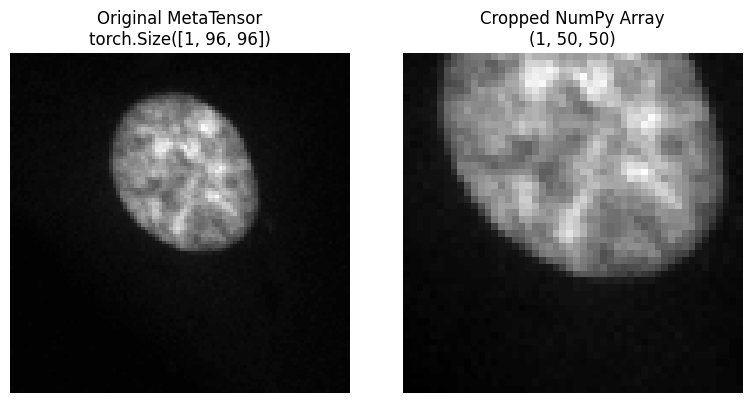

In [ ]:
# Example: Using image_reader for versatile image loading and visualization
from monai.transforms import SpatialCrop
import matplotlib.pyplot as plt

# 1. Load a single image and return it as a MetaTensor (default)
img_path = './data_examples/0450_1.hdf5/clean/10'
mt_single = image_reader(img_path, channels="CYX")
print(f"Single image shape: {mt_single.shape} | Type: {type(mt_single).__name__}")

# 2. Load with on-the-fly transformations (cropping) and return as a NumPy array
np_arr = image_reader(
    img_path, 
    transforms=[SpatialCrop(roi_center=(48, 48), roi_size=(50, 50))], 
    output="nparray", 
    channels="CYX"
)
print(f"Cropped NumPy shape: {np_arr.shape} | Type: {type(np_arr).__name__}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original image (selecting the first channel [0] to get a 2D YX matrix)
axes[0].imshow(mt_single[0], cmap='gray')
axes[0].set_title(f"Original MetaTensor\n{mt_single.shape}")
axes[0].axis('off')

# Cropped numpy array
axes[1].imshow(np_arr[0], cmap='gray')
axes[1].set_title(f"Cropped NumPy Array\n{np_arr.shape}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
from monai.transforms import SpatialCrop
import numpy as np
import warnings

def test_image_reader():
    # Variables aisladas recreadas de los ejemplos HDF5 anteriores
    f = './data_examples/0450_1.hdf5/clean/10'
    im_shape = (1, 96, 96)
    
    # Test image_reader for transformations recording
    out_crop = image_reader(f, transforms=[SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))], output="tensor+meta")
    test_eq(len(out_crop[1]['transforms']) > 0, True)
    test_eq(''.join(out_crop[1]['transforms']), "SpatialCrop")

    # Test image_reader single file outputs
    t_mt = image_reader(f, output="metatensor")
    test_eq(type(t_mt).__name__, "MetaTensor")
    test_eq(isinstance(t_mt.meta, dict), True)

    arr_np = image_reader(f, output="nparray", channels="CYX")
    test_eq(isinstance(arr_np, np.ndarray), True)
    test_eq(arr_np.shape, im_shape)

    arr_meta, meta_np = image_reader(f, output="nparray+meta", channels="CYX")
    test_eq(tuple(meta_np["size_loaded"]), im_shape)

    t_raw = image_reader(f, channels="CYX")
    test_eq(t_raw.shape, im_shape)

    t_meta, meta_t = image_reader(f, output="tensor+meta", channels="CYX")
    test_eq(tuple(meta_t["size_loaded"]), im_shape)

    # Test image_reader multi-sequence stacking behavior
    arr_multi = image_reader([f, f], output="nparray")
    test_eq(arr_multi.shape, (2, 1, 96, 96))

    arr_m_meta, metas_np = image_reader([f, f], output="nparray+meta")
    test_eq(len(metas_np), 2)

    t_multi = image_reader([f, f], output="tensor")
    test_eq(t_multi.shape, (2, 1, 96, 96))

    t_m_meta, metas_t = image_reader([f, f], output="tensor+meta")
    test_eq(len(metas_t), 2)

    t_mt_multi = image_reader([f, f], output="metatensor")
    test_eq(t_mt_multi.data.shape[0], 2)

    t_layout = image_reader([f, f], output="metatensor", channels="ZYX")
    test_eq(t_layout.shape, (2, 1, 96, 96))

    # Test image_reader with list of dictionary items
    d_paths = {"images": ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff']}
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_dict_paths = image_reader(d_paths["images"], output="metatensor", channels="ZYX")
        
    test_eq(t_dict_paths.shape, (2, 96, 512, 512))
    
    return "image_reader tests passed"

test_eq(test_image_reader(), "image_reader tests passed")

#### `image_reader` Parameter Reference

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`file_path`** | `PathLike` \| `Sequence[PathLike]` | *Required* | Path to a single image or a list of paths. |
| **`lazy`** | `bool` | `False` | If `True` and multiple paths are provided, streams images lazily instead of eagerly loading them into memory. |
| **`output`** | `str` | `"metatensor"` | Defines the returned object. Options: `"metatensor"`, `"tensor"`, `"tensor+meta"`, `"nparray"`, `"nparray+meta"`. |
| **`transforms`** | `Callable` \| `list[Callable]` \| `None` | `None` | Preprocessing functions (e.g., MONAI transforms) applied immediately after loading. |
| **`channels`** | `str` | `"CZYX"` | Target dimensional layout. The reader will reorder or pad dimensions to match this string. |
| **`ind_dict`** | `dict` \| `None` | `None` | A dictionary specifying slices to load only partial data (e.g., `{'Z': slice(0, 10)}`). |
| **`dtype`** | `torch.dtype` | `torch.float32` | Target datatype for the output tensor. |
| **`squeeze`** | `bool` | `False` | If `True`, removes all singleton dimensions (`size=1`) from the loaded tensor. |
| **`stack_axis`** | `str` | `"C"` | The axis character used to stack images when a sequence of `file_path` is passed. |
| **`**kwargs`** | `kwargs` | | Additional loader-specific arguments (e.g., `use_aicspylibczi=True` for CZI files). |

In [ ]:
#| export
def image_reader_dict(
    data: dict,
    keys: str | Iterable[str],
    lazy: bool = False,
    output: str = "metatensor",
    transforms: Callable | list[Callable] | None = None,
    channels: str = "CZYX",
    ind_dict: dict | None = None,
    dtype: torch.dtype = torch.float32,
    squeeze: bool = False,
    stack_axis: str = "C",
    **kwargs,
):
    """
    Load images from dictionary keys.

    Supports:
        - single or multi-image entries
        - eager or lazy loading
        - tensor / numpy / MetaTensor outputs
        - metadata preservation

    Parameters
    ----------
    data:
        Input dictionary containing image paths.

    keys:
        Dictionary keys containing image paths or sequences of paths.

    lazy:
        If True, multi-image sequences are streamed lazily.

    output:
        Output representation.

        Supported values:
            - "metatensor"
            - "tensor"
            - "tensor+meta"
            - "nparray"
            - "nparray+meta"

    transforms:
        Optional preprocessing transforms.

    channels:
        Axis layout string.

    ind_dict:
        Optional indexing dictionary.

    dtype:
        Output tensor dtype.

    squeeze:
        Remove singleton dimensions.

    stack_axis:
        Axis used when stacking multi-image inputs.

    **kwargs:
        Additional loader-specific arguments.

    Returns
    -------
    dict
        Dictionary with loaded image objects replacing file paths.
    """

    if output not in _OUTPUT_MODES:
        raise ValueError(
            f"Unknown output mode: {output}. "
            f"Expected one of {_OUTPUT_MODES}"
        )

    if not keys:
        return data.copy()

    if isinstance(keys, str):
        keys = [keys]

    out = data.copy()

    def _load(obj):
        return _load_and_preprocess_dict(
            obj=obj,
            keys=keys,
            transforms=transforms,
            channels=channels,
            ind_dict=ind_dict,
            dtype=dtype,
            **kwargs,
        )

    def _iter_multi(dict_list):

        if lazy:
            return _multi_sequence_stream_dict(
                objs=dict_list,
                keys=keys,
                transforms=transforms,
                channels=channels,
                ind_dict=ind_dict,
                dtype=dtype,
                **kwargs,
            )

        return [_load(d) for d in dict_list]

    for k in keys:

        if k not in out:
            continue

        obj = out[k]

        is_multi = (
            isinstance(obj, Sequence)
            and not isinstance(obj, (str, Path))
        )

        # =====================================================
        # MULTI-IMAGE CASE
        # =====================================================

        if is_multi:

            dict_list = [{k: p} for p in obj]

            loaded = _iter_multi(dict_list)

            metatensors = [d[k] for d in loaded]

            metatensor = _stack(
                metatensors,
                stack_axis=stack_axis,
                channels=channels,
                squeeze=squeeze,
            )

            metatensor.meta.update(
                _meta_from_layout(
                    metatensor.shape,
                    metatensor.meta["layout"],
                )
            )

            out[k] = _format_output(
                output=output,
                metatensor=metatensor,
                metatensors=metatensors,
            )

        # =====================================================
        # SINGLE-IMAGE CASE
        # =====================================================

        else:

            loaded = _load({k: obj})

            metatensor = loaded[k]

            if squeeze:
                metatensor = metatensor.squeeze()

            metatensor.meta.update(
                _meta_from_layout(
                    metatensor.shape,
                    channels,
                    meta=metatensor.meta,
                )
            )

            out[k] = _format_output(
                output=output,
                metatensor=metatensor,
            )

    return out


In [ ]:
show_doc(image_reader_dict)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1435){target="_blank" style="float:right; font-size:smaller"}

### image_reader_dict

```python

def image_reader_dict(
    data:dict, keys:str | collections.abc.Iterable[str], lazy:bool=False, output:str='metatensor',
    transforms:collections.abc.Callable | list[collections.abc.Callable] | None=None, channels:str='CZYX',
    ind_dict:dict | None=None, dtype:dtype=torch.float32, squeeze:bool=False, stack_axis:str='C', kwargs:VAR_KEYWORD
): # Dictionary with loaded image objects replacing file paths.


```

*Load images from dictionary keys.*

Supports:
    - single or multi-image entries
    - eager or lazy loading
    - tensor / numpy / MetaTensor outputs
    - metadata preservation

Loaded image shape: torch.Size([2, 96, 96])
Image tensor type:  MetaTensor
Label preserved:    class_A


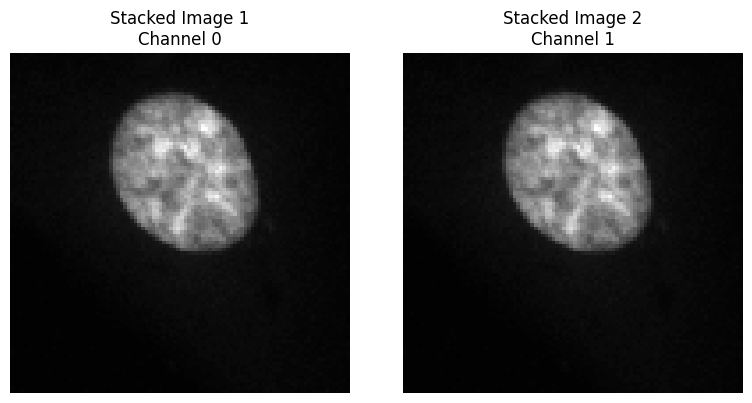

In [ ]:
# Example: Loading dictionary-based data for MONAI pipelines and visualization
from monai.transforms import ScaleIntensityd
import matplotlib.pyplot as plt

# 1. Define a dictionary containing paths and other metadata (e.g., labels)
data_dict = {
    'image': ['./data_examples/0450_1.hdf5/clean/10', './data_examples/0450_1.hdf5/clean/10'],
    'label': 'class_A'
}

# 2. Load the 'image' key, stack the multi-image sequence, and apply a dictionary transform
loaded_dict = image_reader_dict(
    data=data_dict,
    keys='image',
    transforms=[ScaleIntensityd(keys='image')],
    channels="CYX"
)

# 3. The dictionary is updated in-place with the loaded tensors
print(f"Loaded image shape: {loaded_dict['image'].shape}")
print(f"Image tensor type:  {type(loaded_dict['image']).__name__}")
print(f"Label preserved:    {loaded_dict['label']}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# We stacked two identical 2D images along the channel dimension ("C").
# Plot the first stacked image (Channel 0)
axes[0].imshow(loaded_dict['image'][0], cmap='gray')
axes[0].set_title(f"Stacked Image 1\nChannel 0")
axes[0].axis('off')

# Plot the second stacked image (Channel 1)
axes[1].imshow(loaded_dict['image'][1], cmap='gray')
axes[1].set_title(f"Stacked Image 2\nChannel 1")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
from monai.transforms import ScaleIntensityd
import warnings

def test_image_reader_dict():
    # Test image_reader_dict with single and multi-sequence keys
    dd = {
        'image': ['./data_examples/example_tiff.tiff', './data_examples/example_tiff.tiff'], 
        'label': 'a'
    }
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res_dict = image_reader_dict(dd, keys='image', transforms=ScaleIntensityd(keys='image'))

    # Verifications of types, shapes, and metadata extraction
    test_eq(type(res_dict['image']).__name__, "MetaTensor")
    test_eq(res_dict['image'].shape, (2, 96, 512, 512))
    test_eq(res_dict['image'].meta['layout'], "CZYX")
    test_eq(res_dict['image'].meta['mode'], "multichannel (2)")
    
    # Verify non-image keys are left intact
    test_eq(res_dict['label'], 'a')
    
    return "image_reader_dict tests passed"

test_eq(test_image_reader_dict(), "image_reader_dict tests passed")

#### `image_reader_dict` Parameter Reference

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`data`** | `dict` | *Required* | Input dictionary containing image paths and other metadata/labels. |
| **`keys`** | `str` \| `Iterable[str]` | *Required* | The dictionary keys specifying which entries contain file paths to load. |
| **`lazy`** | `bool` | `False` | If `True` and multiple paths are provided, streams images lazily instead of eagerly loading them. |
| **`output`** | `str` | `"metatensor"` | Defines the returned object. Options: `"metatensor"`, `"tensor"`, `"tensor+meta"`, `"nparray"`, `"nparray+meta"`. |
| **`transforms`** | `Callable` \| `list[Callable]` \| `None` | `None` | Preprocessing functions (e.g., MONAI dictionary transforms) applied immediately after loading. |
| **`channels`** | `str` | `"CZYX"` | Target dimensional layout. Reorders or pads dimensions to match this string. |
| **`ind_dict`** | `dict` \| `None` | `None` | A dictionary specifying slices to load only partial data (e.g., `{'Z': slice(0, 10)}`). |
| **`dtype`** | `torch.dtype` | `torch.float32` | Target datatype for the output tensor. |
| **`squeeze`** | `bool` | `False` | If `True`, removes all singleton dimensions (`size=1`) from the loaded tensor. |
| **`stack_axis`** | `str` | `"C"` | The axis character used to stack images when a sequence of paths is passed. |
| **`**kwargs`** | `kwargs` | | Additional loader-specific arguments. |

### Runtime Reader
> The `BioImageReader` class acts as a bridge between our universal `image_reader` function and the MONAI ecosystem. By subclassing MONAI's `ImageReader`, it exposes standard interfaces, allowing you to seamlessly plug our bioimage loading engine directly into standard MONAI pipelines and transforms (like `LoadImage` or `LoadImaged`).

* **Interface compliance:** Implements `read`, `get_data`, and `verify_suffix` to support native MONAI dictionary transforms.
* **On-the-fly conversion:** Includes an optional `converter` hook for applying custom tensor operations post-loading.
* **Format-agnostic:** Automatically verifies if input files are supported by the registry via the `verify_suffix` method.

In [ ]:
#| export
class BioImageReader(ImageReader):
    def __init__(
        self,
        converter: Callable[[MetaTensor], MetaTensor] | None = None,  # A callable that takes a MetaTensor and returns a MetaTensor
        reverse_indexing: bool = False,
        **kwargs,
    ):
        super().__init__()
        self.converter = converter
        self.reverse_indexing = reverse_indexing
        self.kwargs = kwargs

    # --------------------------------------------------
    def verify_suffix(self, filename:Sequence[PathLike] | PathLike) -> bool:
        suffixes = self._get_supported_suffixes()
        return is_supported_format(filename, suffixes)


    def _get_supported_suffixes(self) -> list[str]:
        """
        Collect supported suffixes from loader registry removing leading dots.
        """
        # Extract keys from the inner registry dictionary and flatten any nested structures
        return [ext.lstrip('.') for ext in LOADER_REGISTRY._loaders.keys()]

    # --------------------------------------------------
    def read(self, data: PathLike | Sequence[PathLike] | np.ndarray, **kwargs) -> MetaTensor:
        kwargs_ = {**self.kwargs, **kwargs}
        
        if isinstance(data, Sequence) and not isinstance(data, (str, Path)) and len(data) == 1:
            data = data[0]

        mt = image_reader(
            data,
            **kwargs_,
        )

        if self.converter:
            mt = self.converter(mt)

        return mt

    # --------------------------------------------------
    def get_data(self, img: MetaTensor) -> tuple[np.ndarray, dict]:

        if self.reverse_indexing and img.ndim >= 2:
            img = MetaTensor(
                x=img.swapaxes(-1, -2),
                meta=img.meta,
            )

        # extract numpy array
        array = img.as_tensor().cpu().numpy()

        # ensure plain dict
        meta = dict(img.meta)

        return array, meta 
    
    def _get_spatial_shape(self, img: MetaTensor):
        m = img.meta
        spatial_shape = m.get(MetaKeys.SPATIAL_SHAPE)
        if spatial_shape is not None:
            return tuple(reversed(spatial_shape))
        return tuple(
            v for v in (
                m.get("width", m.get("image_size_x")),
                m.get("height", m.get("image_size_y")),
                m.get("depth", m.get("image_size_z")),
            )
            if v is not None
        )


In [ ]:
show_doc(BioImageReader)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/io.py#L1619){target="_blank" style="float:right; font-size:smaller"}

### BioImageReader

```python

def BioImageReader(
    converter:collections.abc.Callable[[monai.data.meta_tensor.MetaTensor], monai.data.meta_tensor.MetaTensor] | None=None, # A callable that takes a MetaTensor and returns a MetaTensor
    reverse_indexing:bool=False, kwargs:VAR_KEYWORD
):


```

*An abstract class defines APIs to load image files.*

Typical usage of an implementation of this class is:

.. code-block:: python

    image_reader = MyImageReader()
    img_obj = image_reader.read(path_to_image)
    img_data, meta_data = image_reader.get_data(img_obj)

- The `read` call converts image filenames into image objects,
- The `get_data` call fetches the image data, as well as metadata.
- A reader should implement `verify_suffix` with the logic of checking the input filename
  by the filename extensions.

Tensor shape: torch.Size([1, 96, 96])


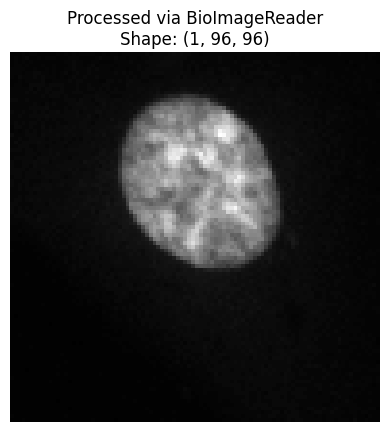

In [ ]:
# Example: Using BioImageReader as a MONAI-compatible reader
from monai.transforms import ScaleIntensity
import matplotlib.pyplot as plt

# 1. Initialize the reader with desired channel layout and on-the-fly transforms
reader = BioImageReader(
    channels="CYX", 
    transforms=[ScaleIntensity()]
)

# 2. Read the file into a MetaTensor using the standard MONAI interface
img_tensor = reader.read('./data_examples/0450_1.hdf5/clean/10')
print(f"Tensor shape: {img_tensor.shape}")

# 3. Unpack into a plain NumPy array and a pure metadata dictionary using get_data()
img_array, img_meta = reader.get_data(img_tensor)

# --- Visualization ---
plt.imshow(img_array[0], cmap='gray')
plt.title(f"Processed via BioImageReader\nShape: {img_array.shape}")
plt.axis('off')
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
from monai.transforms import ScaleIntensity, SpatialCrop
import warnings
import numpy as np

def test_bioimage_reader():
    # Setup transforms and reader
    imtransforms = [ScaleIntensity(), SpatialCrop(roi_center=(0,10,10), roi_size=(1,5,5))]
    reader = BioImageReader(channels="CZYX", transforms=imtransforms)

    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Test read operation
        t_reader = reader.read('./data_examples/example_tiff.tiff')
        test_eq(t_reader.shape, (1, 1, 5, 5))
        test_eq(isinstance(t_reader.meta, dict), True)
        test_eq(t_reader.meta['layout'], "CZYX")

        # 2. Test get_data unpacker
        arr_reader, meta_reader = reader.get_data(t_reader)
        test_eq(isinstance(arr_reader, np.ndarray), True)
        test_eq(arr_reader.shape, (1, 1, 5, 5))
        test_eq(meta_reader, t_reader.meta)

        # 3. Test verification methods
        test_eq(reader.verify_suffix('sample.tiff'), True)
        test_eq(reader._get_spatial_shape(t_reader), (5, 5, 1))

    return "BioImageReader tests passed"

test_eq(test_bioimage_reader(), "BioImageReader tests passed")

#### `BioImageReader` Parameter Reference

| Parameter | Type | Default | Description |
| :--- | :--- | :--- | :--- |
| **`converter`** | `Callable` \| `None` | `None` | Optional function applied to the `MetaTensor` after reading (e.g., for normalization). |
| **`reverse_indexing`** | `bool` | `False` | If `True`, swaps the last two axes (H/W) during `get_data`, useful for matching legacy data layouts. |
| **`**kwargs`** | `kwargs` | | Additional arguments passed to the underlying `image_reader` (e.g., `channels`, `dtype`). |

### Image Loaders
> Seamless integration with MONAI's native transform ecosystem. By re-exporting `LoadImage` and `LoadImaged`, `bioMONAI` allows you to inject the `BioImageReader` directly into your existing pipelines without modifying your training or inference loops.

* **Native Compatibility**: Fully supports dictionary-based transforms (e.g., `ScaleIntensityd`, `SpatialCropd`).
* **Format-agnostic**: Once the reader is injected, standard MONAI loaders automatically become "bio-aware" and capable of handling complex formats (TIFF, HDF5, CZI) transparently.
* **Metadata-aware**: Correctly handles the separation of data and metadata as expected by MONAI’s dictionary structures (i.e., `image` vs `image_meta_dict`).

In [ ]:
#| export
from monai.transforms import LoadImage, LoadImaged

# Re-exporting MONAI's standard loaders for convenience within bioMONAI
LoadImage = LoadImage
LoadImaged = LoadImaged

Loaded Shape: torch.Size([1, 96, 96])
Average bioMONAI Load Time: 2.04 ms


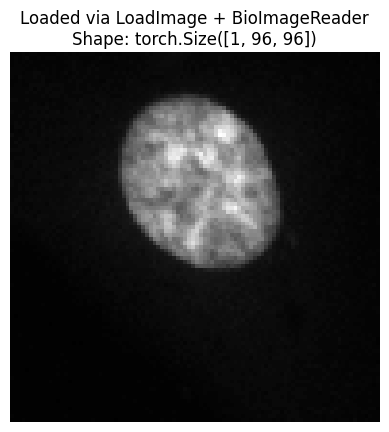

In [ ]:
# Example: Injecting BioImageReader into MONAI's LoadImage and profiling speed
import time
import matplotlib.pyplot as plt
from monai.transforms import LoadImage

# 1. Initialize the standard MONAI loader with our custom bioimage reader
bio_loader = LoadImage(reader=BioImageReader(channels="CYX"), image_only=True)

# 2. Warmup (to compile any underlying C/JIT code and cache file handles)
img = bio_loader('./data_examples/0450_1.hdf5/clean/10')

# 3. Benchmark
N = 50
start = time.perf_counter()
for _ in range(N):
    img = bio_loader('./data_examples/0450_1.hdf5/clean/10')
elapsed = time.perf_counter() - start

print(f"Loaded Shape: {img.shape}")
print(f"Average bioMONAI Load Time: {elapsed / N * 1000:.2f} ms")

# 4. Visualization to verify the load
plt.imshow(img[0], cmap='gray')
plt.title(f"Loaded via LoadImage + BioImageReader\nShape: {img.shape}")
plt.axis('off')
plt.show()

In [ ]:
#| hide
from fastcore.test import test_eq
import warnings

def test_monai_integration():
    # Test seamless integration of BioImageReader with MONAI's transforms
    file_path = './data_examples/example_tiff.tiff'
    custom_reader = BioImageReader(channels="CZYX")
    
    # Silenciamos el warning inofensivo de 'ResolutionUnit' de bioio_tifffile
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        # 1. Test LoadImage (Tensor integration)
        # Using image_only=False to ensure metadata is passed correctly through MONAI
        loader = LoadImage(reader=custom_reader, image_only=False)
        img_data, img_meta = loader(file_path)
        
        test_eq(img_data.shape, (1, 96, 512, 512))
        test_eq(img_meta['format'], 'TIFF')
        test_eq(img_meta['layout'], 'CZYX')
        
        # 2. Test LoadImaged (Dictionary integration)
        loader_d = LoadImaged(keys=["image"], reader=custom_reader, image_only=False)
        res_dict = loader_d({"image": file_path, "label": "test"})
        
        # In dict mode, MONAI stores metadata in a separate key (image_meta_dict)
        test_eq(res_dict["image"].shape, (1, 96, 512, 512))
        test_eq(res_dict["image_meta_dict"]["format"], 'TIFF')
        test_eq(res_dict["label"], "test")

    return "MONAI Integration tests passed"

test_eq(test_monai_integration(), "MONAI Integration tests passed")

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()